# Executive Summary



# Key Takeaways
1. The Airline currently experiences a high number of neutral or unhappy customers - for every 100 customers, 56 to 57 will walk off the plane with these sentiments.
2. While Long-Haul passengers are generally more satisfied, statistical analysis reveals a "Duration-Based Sensitivity." For dissatisfied passengers, the negative impact of poor service, seating, and cleanliness is significantly magnified by flight length, leading to harsher brand scoring compared to Short-Haul counterparts.
3. Don't be fooled by delays! Delays are frustrating but there is little evidence to suggest that increased delay time increases the number of unhappy customers. The real problem lies within combined Arrival & Departure delays. Using Bayesian probability modelling, I can state with confidence that P(unhappy | departure and arrival delay) is ~61% compared to ~54% for departure delay alone — a 7% difference with meaningful implications for operational prioritisation.

# Action Points
1. **Proactive Service Standards:** Shift from reactive "call-bell" service to a Proactive Engagement Model. Mandate rhythmic cabin "check-ins" and transparent, frequent communication regarding operational delays to reduce passenger anxiety.
2. **Physical Comfort Mitigation:** Recognising that aircraft seating is a fixed asset, mitigate physical fatigue by providing Ergonomic Comfort Kits (lumbar cushions/enhanced blankets).
3. **Hygiene & Turnaround Audits:** Implement a mandatory Pre-Boarding Readiness Survey. Elevate cleanliness from a "task" to a "priority gate." A formal review of cleaning vendor contracts is advised to ensure deeper sanitisation across the long-haul fleet. Finally, On-Board regular cleaning activities is advised, showing customers you care about their environment cleanliness.
4. **Food & Drink Offerings** For any sort of delay in flight, offer free food and/or drink to the customers as a way to say sorry. I would also recommend running experiments to see the impact of such offerings to customer satisfaction.

# Machine Learning Outcome
1. **Overlooked Drivers**: Flight class, specifically 'Eco Plus', emerged as a surprisingly powerful predictor of dissatisfaction, highlighting the hidden value in less obvious data features.
2. **Validating the Data**: Custom feature engineering, such as delay bucketing, successfully captured critical signals, proving that targeted customer recovery strategies are essential.
3. **Algorithmic Bias Risk**: The model assigns a high predictive weight to gender (male). Immediate investigation is required to ensure this reflects genuine demographic trends rather than unethical model bias that could skew business decisions.
4. **Targeted Interventions**: The business must launch Continuous Improvement (CI) initiatives tailored to specific flight classes. Uncovering exactly why these specific tiers are unhappy is our fastest route to drastically reducing customer churn.

# Library Imports

In [1]:
# libraries

# data analysis
import numpy as np 
import pandas as pd 
import scipy.stats as stats


# Data viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

# ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier


# preporcessing
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline

# feature selection
from sklearn.feature_selection import RFE
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# cross validation
from sklearn.model_selection import cross_val_score

# Model performance metrics
from sklearn.metrics import confusion_matrix, classification_report

# set the style
sns.set_style("whitegrid")
# set palette
sns.set_palette(sns.color_palette('rocket'))
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/train.csv
/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/test.csv


# Data Import & Basic Review

In [2]:
# set train and test dfs
train_df = pd.read_csv('/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/test.csv')

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [3]:
# lets review our dataset's dtype by counting how many there are by dtype
train_df.dtypes.value_counts()

int64      19
object      5
float64     1
Name: count, dtype: int64

**Notes**

Looks like this dataset contains mostly numeric columns

In [4]:
# review the shape of the data
print(f"Row Count: {train_df.shape[0]}")
print(f"Column Count: {train_df.shape[1]}")

Row Count: 103904
Column Count: 25


In [5]:
# for the object columns, what are the values?
ob_df = train_df.select_dtypes(include=['object']).copy()

# count the unique values
n_unique = ob_df.nunique().sort_values()

# get unqiue value list
unique_values = ob_df.apply(lambda x: x.unique())

# get sample siuze
sample_size = ob_df.count()

# drop results in df
pd.DataFrame({
        "Unique Value Count":n_unique,
        "Unique Values":unique_values,
        "Data Sample Size":sample_size
})

,Unique Value Count,Unique Values,Data Sample Size
Class,3,"[Eco Plus, Business, Eco]",103904
Customer Type,2,"[Loyal Customer, disloyal Customer]",103904
Gender,2,"[Male, Female]",103904
Type of Travel,2,"[Personal Travel, Business travel]",103904
satisfaction,2,"[neutral or dissatisfied, satisfied]",103904


**Notes**

Appears we have consistent categoric data where our target has only two outcomes.

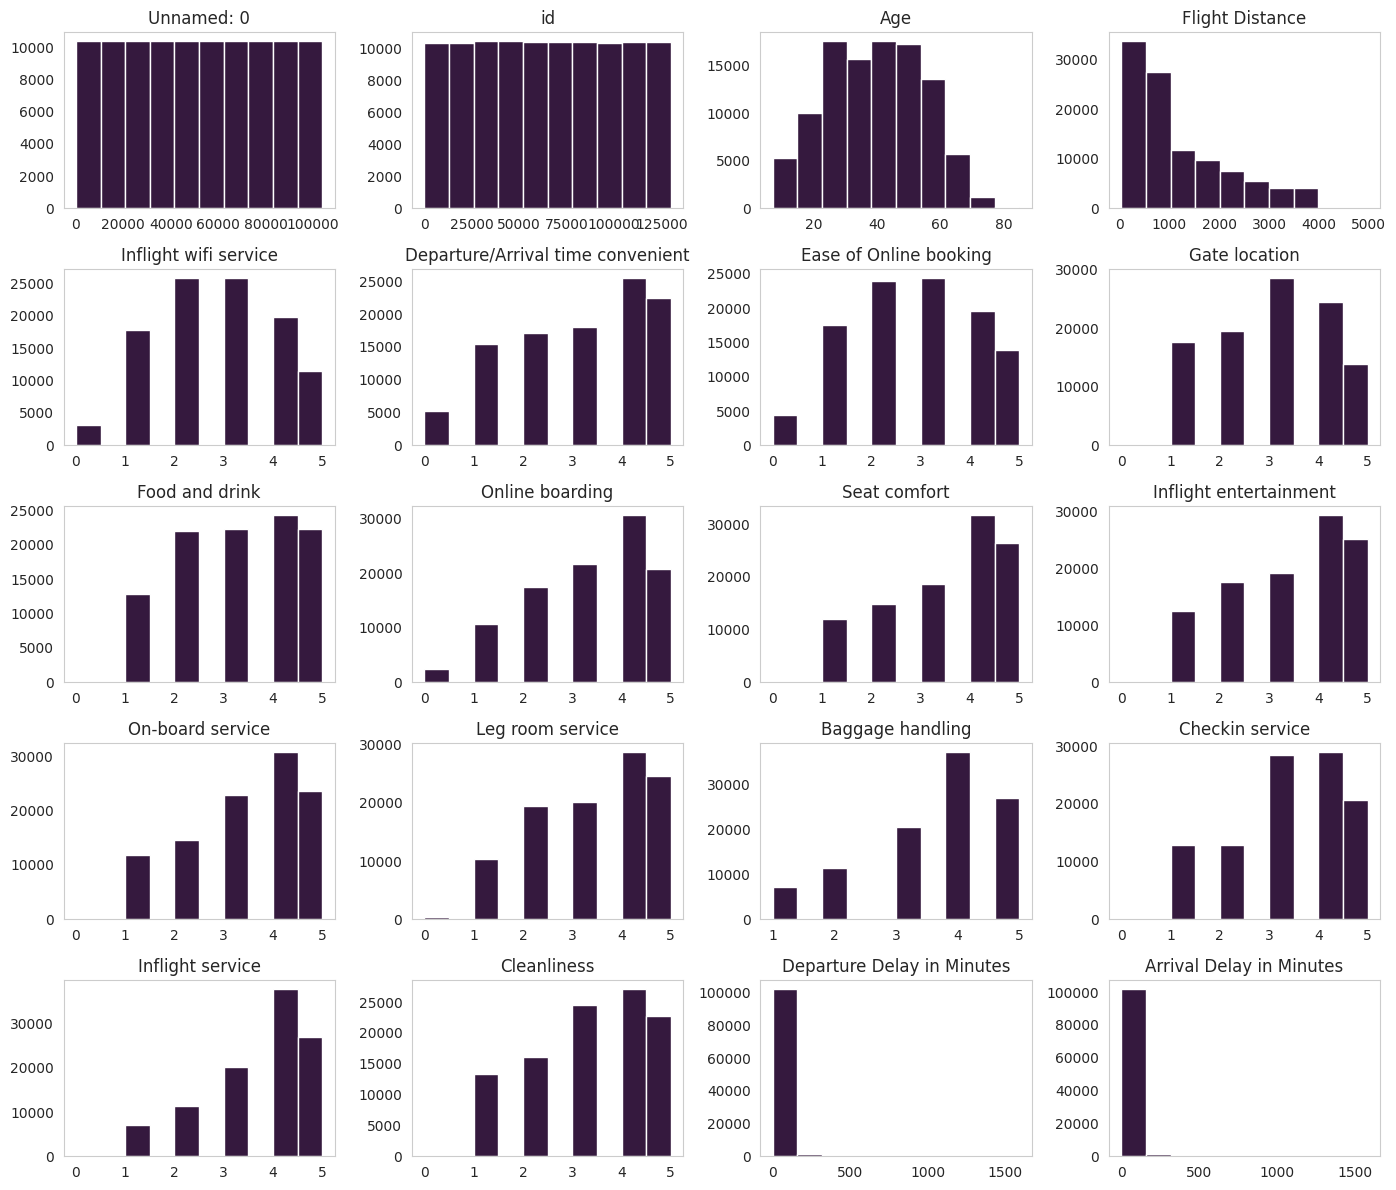

In [6]:
# review data distributions of all numeric columns.
# we only reall want to see the range and shape of the distributions

num_df = train_df.select_dtypes(exclude=['object']).copy()

num_df.hist(
    figsize=(14,12),
    grid=False
);

plt.tight_layout()

**Notes**

The majority of the features are likertscale features where the passenger has rated the service on a scale of 1 to 5.

We then have 4 columns containing data sourrounding the actual flight such as delay time in departure and arrival time.

# Data Cleaning

In this section, I will identify and action cleaning methods to ensure good data is fed into our ML model.

## Missing Data

In [7]:
# quickly verify if we have NaN

train_df.isna().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [8]:
test_df.isna().sum()

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


**Notes**

Looks like it is just one column conaining missing data - Arrival Delay in Minutes

In [9]:
# what are these NaN? is there a pattern?
mask = train_df['Arrival Delay in Minutes'].isna()

train_df.loc[mask].head(10)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
213,213,49608,Female,Loyal Customer,38,Business travel,Eco,109,5,3,...,5,5,2,4,1,1,5,31,NaN,satisfied
1124,1124,73442,Male,Loyal Customer,53,Personal Travel,Eco,1012,3,2,...,4,4,4,4,3,3,4,38,NaN,neutral or dissatisfied
1529,1529,71178,Male,Loyal Customer,39,Business travel,Business,733,2,5,...,2,2,2,2,2,2,3,11,NaN,neutral or dissatisfied
2004,2004,72940,Female,disloyal Customer,26,Business travel,Business,1035,3,3,...,2,3,3,4,5,5,2,41,NaN,neutral or dissatisfied
2108,2108,116374,Female,Loyal Customer,24,Personal Travel,Eco,417,2,1,...,5,1,4,2,1,2,5,1,NaN,neutral or dissatisfied
2485,2485,121173,Female,Loyal Customer,28,Personal Travel,Eco,2370,4,5,...,3,5,4,4,5,4,3,3,NaN,satisfied
2630,2630,3638,Male,Loyal Customer,35,Business travel,Business,1534,1,1,...,5,5,5,5,5,5,5,0,NaN,satisfied
3621,3621,48387,Male,Loyal Customer,47,Personal Travel,Eco,587,1,2,...,4,1,1,4,4,4,4,17,NaN,neutral or dissatisfied
4041,4041,66091,Male,Loyal Customer,31,Business travel,Business,2490,1,1,...,4,3,5,5,4,4,4,6,NaN,satisfied
4490,4490,48504,Male,disloyal Customer,30,Business travel,Eco,737,4,4,...,2,5,1,4,1,3,2,22,NaN,neutral or dissatisfied


                            Departure Delay in Minutes  \
Departure Delay in Minutes                    1.000000   
Arrival Delay in Minutes                      0.965481   

                            Arrival Delay in Minutes  
Departure Delay in Minutes                  0.965481  
Arrival Delay in Minutes                    1.000000  


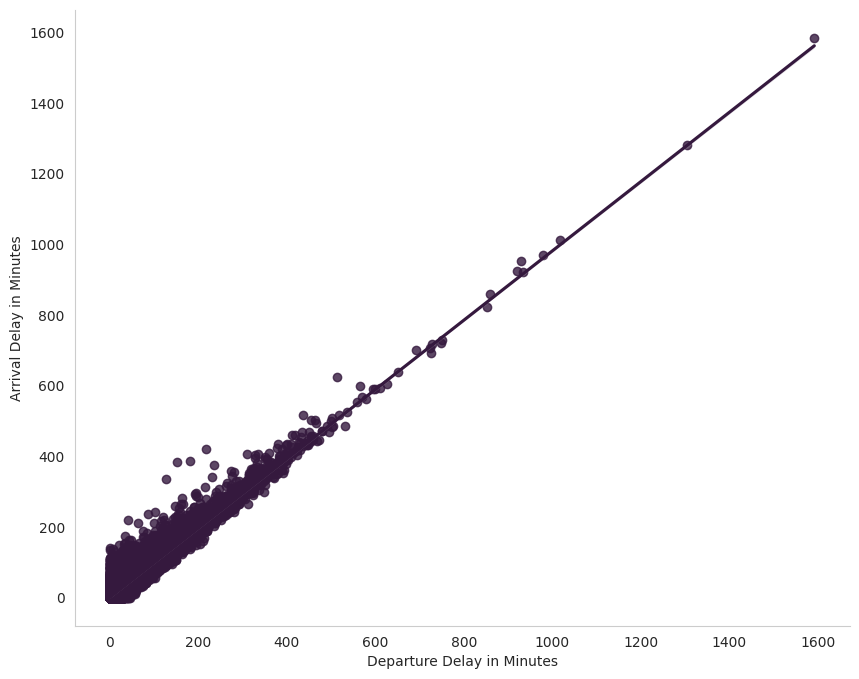

In [10]:
# lets show the relationship between departure delay and arrival delay. Does a departure delay mean a high arrival delay?

# shor corr
mask = train_df['Arrival Delay in Minutes'].isna() == False
r = train_df[['Departure Delay in Minutes','Arrival Delay in Minutes']].loc[mask].corr()
print(r)

# viz
plt.figure(
    figsize=(10,8)
)

sns.regplot(
    data=train_df,
    x='Departure Delay in Minutes',
    y='Arrival Delay in Minutes'
);

sns.despine()
plt.grid(False)

**Notes**

There is a strong Correlation between the two variables, but is you look in the bottom corner of the graph something tells that there are caveats. In other words, the linear relationship breaks down when the departure delay is between 0 and 25 minutes due to that observed cluster, but as time goes on so does the arrival delay. This means that in that cluster of departure delays, there are multiple factors influencing the arrival delay as we have 0 departure delay with an arrival delay between 1 and 50 minutes.

Departure Delay in Minutes
0     116
1       9
2       8
3       3
4       9
5       4
6       3
7       2
8       2
9       1
10      4
11      3
12      3
13      1
14      1
Name: id, dtype: int64


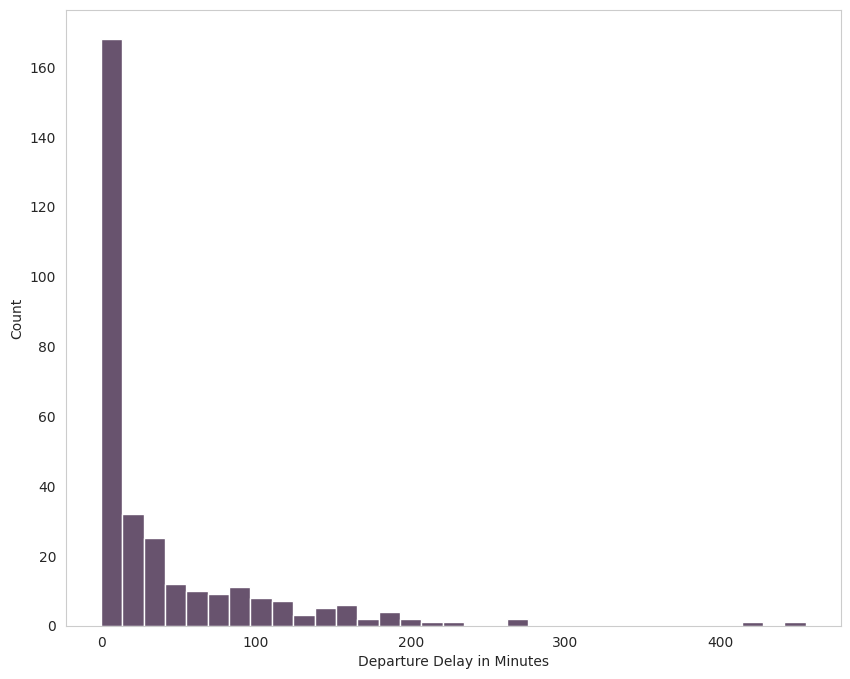

In [11]:
# lets identify the NaN data distribution and see what we have
mask = train_df['Arrival Delay in Minutes'].isna()

missing_data = train_df.loc[mask]

# lets print the groups of data
dist = (
    missing_data
    .groupby('Departure Delay in Minutes')['id']
    .nunique()
    .head(15)
)
print(dist)
# viz
plt.figure(
    figsize=(10,8)
)


sns.histplot(
    data=missing_data,
    x='Departure Delay in Minutes'
);

plt.grid(False)

count    89166.000000
mean         4.547013
std          9.655574
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max        148.000000
Name: Arrival Delay in Minutes, dtype: float64


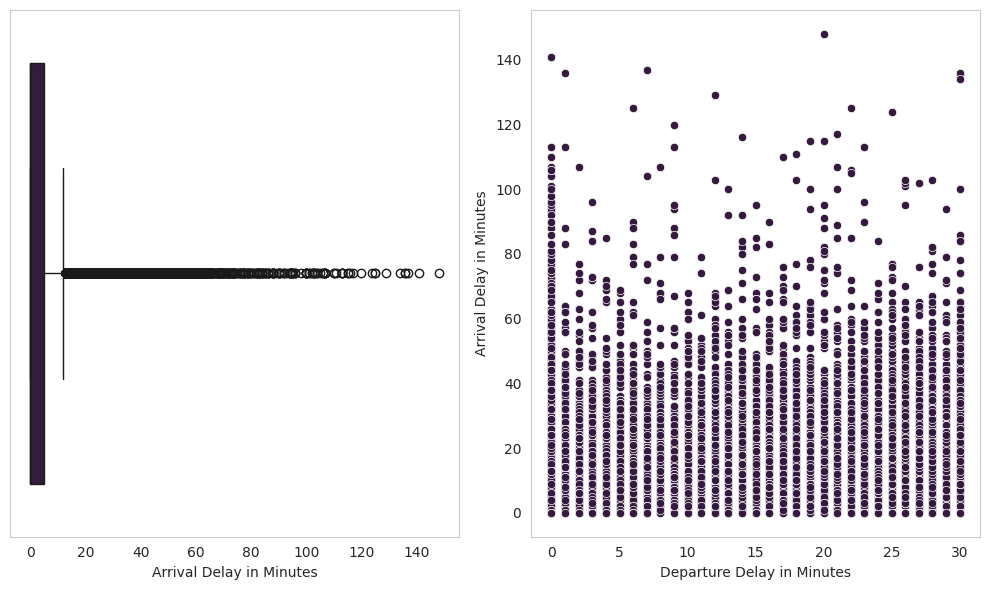

In [12]:
# what is the distribution of Arrival Delay in Minutes where Departure Delay in Minutes is 0
delay_mask = (train_df['Departure Delay in Minutes'] >= 0)& (train_df['Departure Delay in Minutes'] <= 30)

d_delay = train_df['Arrival Delay in Minutes'].loc[delay_mask].describe()

print(d_delay)

# show results
fig, axes = plt.subplots(
    1,2,figsize=(10,6)
)

sns.boxplot(
    data=train_df.loc[delay_mask],
    x='Arrival Delay in Minutes',
    ax=axes[0]
)

sns.scatterplot(
    data=train_df.loc[delay_mask],
    x='Departure Delay in Minutes',
    y='Arrival Delay in Minutes',
    ax=axes[1]
)

for i in range(2):
    axes[i].grid(
        False
    )

plt.tight_layout()

**Notes**

This evidences the above statement that there are other factors at play that influence Arrival Delays - ie weather, queing to land and flight re-routing.

The next question - How do i fill in these gaps?

Lets bucket the data by 30 mins to see what happens to our arrival delay time

In [13]:
# create a function to bucket the data
def departure_bucket(df):

    #create a copy
    df_in = df.copy()
    
    # create the buckets
    bucket = [1, 30, 60, 120, np.inf]

    # create the labels
    labels = [
        '1-30 Minutes',
        '30-60 Minutes',
        '60-120 Minutes',
        '120 Minutes +',
    ]

    # create the feature
    df_in['DepartureDelayBuckets'] = (
        pd.cut(
            df_in['Departure Delay in Minutes'],
            bins=bucket,
            labels=labels,
            right=False
        )
        .cat.add_categories("0 Mins")
        .fillna("0 Mins")
    )
    
    return df_in


# create the feature
train_df2, test_df2 = departure_bucket(train_df),departure_bucket(test_df)

/tmp/ipykernel_57/2227006280.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('DepartureDelayBuckets')['Arrival Delay in Minutes']


                         count   mean   std   min    25%    50%    75%     max
DepartureDelayBuckets                                                         
1-30 Minutes           30165.0    9.0  13.0   0.0    0.0    5.0   15.0   148.0
30-60 Minutes           7553.0   39.0  18.0   0.0   27.0   37.0   48.0   219.0
60-120 Minutes          4773.0   82.0  24.0  20.0   64.0   79.0   97.0   242.0
120 Minutes +           2551.0  195.0  97.0  83.0  137.0  168.0  219.0  1584.0
0 Mins                 58552.0    2.0   6.0   0.0    0.0    0.0    0.0   141.0


<Axes: xlabel='Arrival Delay in Minutes', ylabel='DepartureDelayBuckets'>

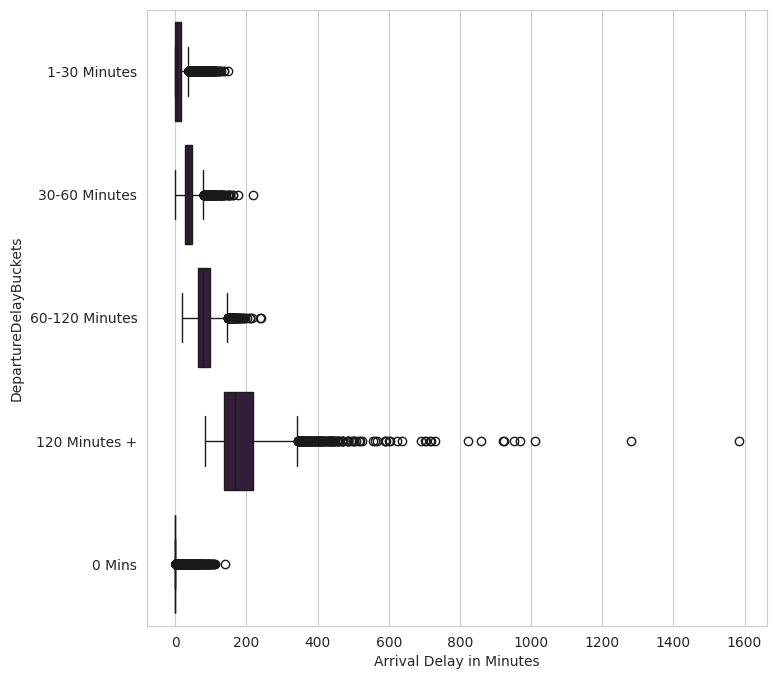

In [14]:
stats_ = (
    train_df2
    .groupby('DepartureDelayBuckets')['Arrival Delay in Minutes']
    .describe()
    .round(0)
)

print(stats_)

# show box plots
plt.figure(
    figsize=(8,8)
)
sns.boxplot(
    data=train_df2,
    x='Arrival Delay in Minutes',
    y='DepartureDelayBuckets'
)

/tmp/ipykernel_57/2774005800.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df2.groupby('DepartureDelayBuckets')['Arrival Delay in Minutes'].transform('mean')


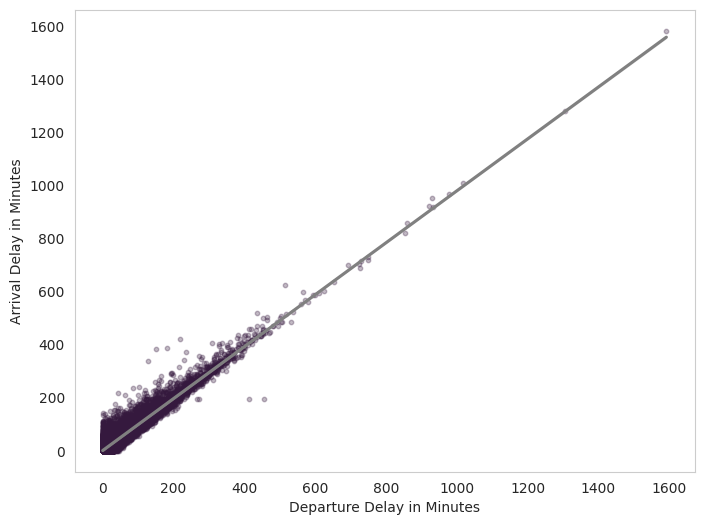

In [15]:

# fill in Nans
train_df2['Arrival Delay in Minutes'] = train_df2['Arrival Delay in Minutes'].fillna(
    train_df2.groupby('DepartureDelayBuckets')['Arrival Delay in Minutes'].transform('mean')
)

plt.figure(
    figsize=(8,6)
)

# check work
sns.regplot(
    data=train_df2,
    x='Departure Delay in Minutes',
    y='Arrival Delay in Minutes',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'grey'}
);

plt.grid(
    False
)


**Notes**

I have imputed the NaN unsucessfully as we now have 2 outlier values. This illustrates the dangers of just using the Mean value to impute missing data and why you should always verify what you have done visually - remember: Rubbish in, Rubbish out!

For every 1 min of departure delay, arrival delay increases by: 0.98 mins
Model R^2 Score: 0.9322


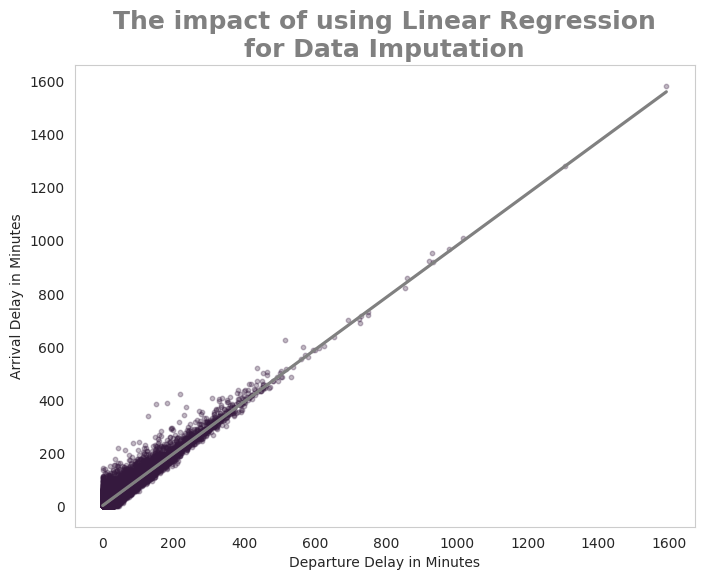

In [16]:
# not quite was i was after!
# lets use linear regression to fill in the blanks!
train_df3,test_df3 = departure_bucket(train_df),departure_bucket(test_df)

# Split data into "has arrival delay" and "missing arrival delay"
train_data = train_df3.dropna(subset=['Arrival Delay in Minutes']).copy()
missing_data = train_df3[train_df3['Arrival Delay in Minutes'].isnull()].copy()
test_missing_data = test_df3[test_df3['Arrival Delay in Minutes'].isnull()].copy()

# Initialize and fit the model
# We use Departure Delay (X) to predict Arrival Delay (y)
model = LinearRegression()

# train and target
X_train = train_data[['Departure Delay in Minutes']]
y_train = train_data['Arrival Delay in Minutes']

# fit the model
model.fit(X_train, y_train)

# Predict the missing value
X_missing = missing_data[['Departure Delay in Minutes']]
X_test_missing = test_missing_data[['Departure Delay in Minutes']]

predicted_values = model.predict(X_missing)
test_predicted = model.predict(X_test_missing)

# Fill the NaNs in the original DataFrame
train_df3.loc[train_df3['Arrival Delay in Minutes'].isnull(), 'Arrival Delay in Minutes'] = predicted_values
test_df3.loc[test_df3['Arrival Delay in Minutes'].isnull(), 'Arrival Delay in Minutes'] = test_predicted

# show scoring and impact of the x-variable has on y - for every x units change by 1, y unit change by n value
print(f"For every 1 min of departure delay, arrival delay increases by: {model.coef_[0]:.2f} mins")
print(f"Model R^2 Score: {model.score(X_train, y_train):.4f}")

# Viz the results

plt.figure(
    figsize=(8,6)
)

sns.regplot(
    data=train_df3,
    x='Departure Delay in Minutes',
    y='Arrival Delay in Minutes',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'grey'}
);

# add title
plt.title(
    "The impact of using Linear Regression\nfor Data Imputation",
    fontsize=18,
    fontweight='bold',
    color='grey'
);

# remove gridlinbes
plt.grid(
    False
)

In [17]:
print(f"Train Set: {train_df3.isna().sum()}")
print("--"*30)
print("  "*30)
print("--"*30)
print(f"Test Set: {test_df3.isna().sum()}")

Train Set: Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
DepartureDelay

**Notes**

In this section, I have completed 2 tasks for both features:

1. Imputed missing values with Linear Regression.
2. Confirmed the large values are not outliers as they change consistently with the x-variable.

## Outliers

In this sectiojn, I will solely focus on Flight Distance as the remaining features appear to contain no outliers due to their nature (likert scale and age values) and the previous subsection confirmations.

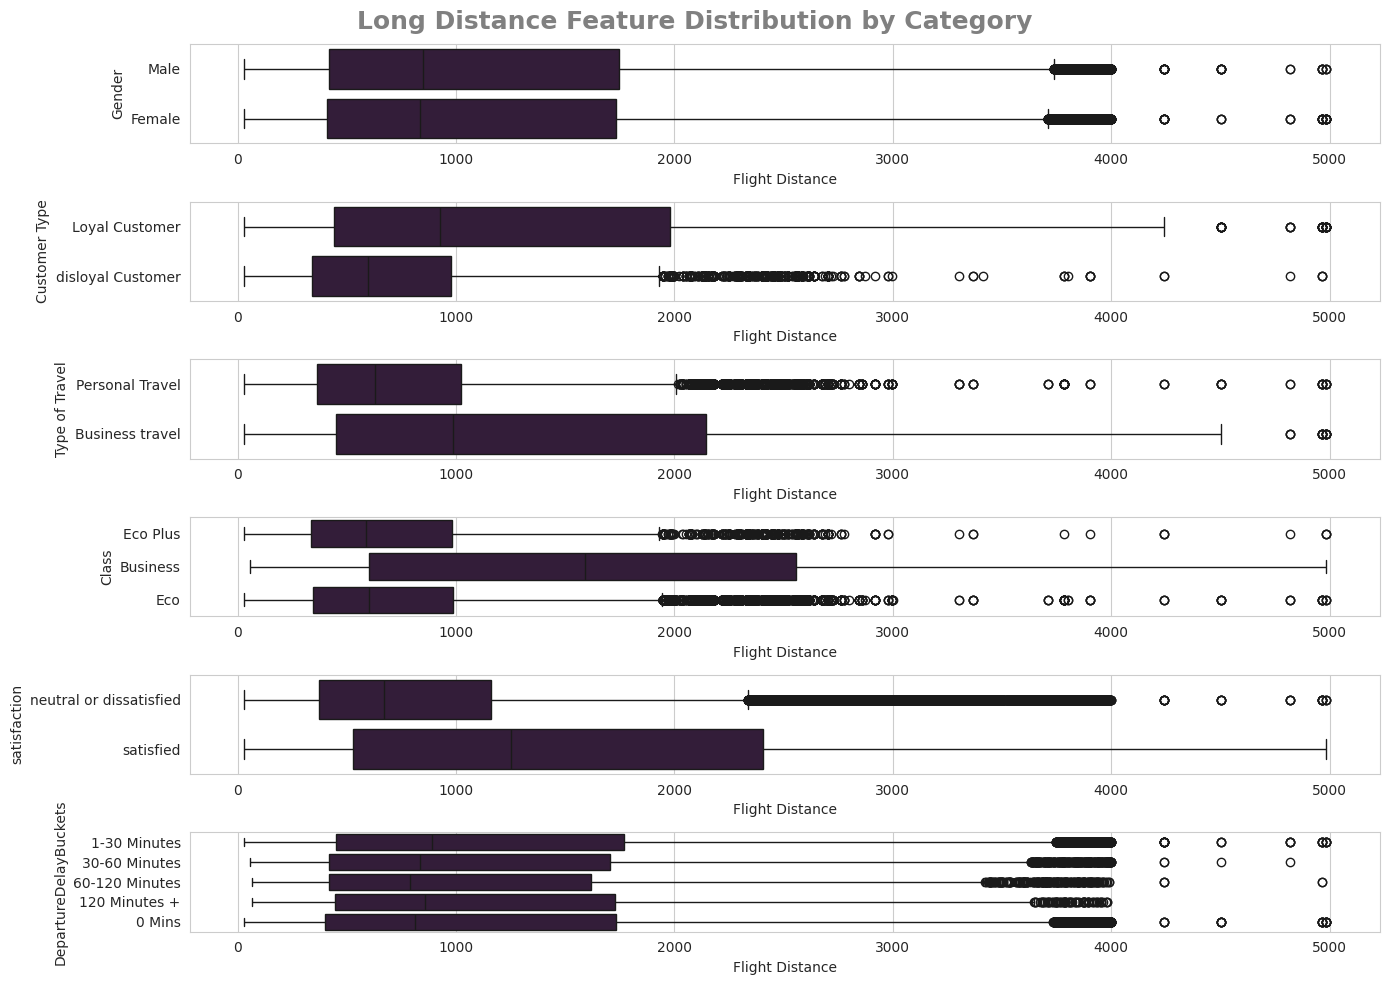

In [18]:
# lets analyse the data by categorix features

fig, axes = plt.subplots(
    6,1, figsize=(14,10)
)
row = 0
col = 0

# loop thorugh the cat columns and show in boxplot
for col in train_df3.select_dtypes(include=['object','category']).columns:
    
    sns.boxplot(
        data=train_df3,
        x='Flight Distance',
        y=col,
        ax=axes[row]
    );
    

    row+=1

# add title
plt.suptitle(
    "Long Distance Feature Distribution by Category",
    fontsize=18,
    fontweight='bold',
    color='grey',
    ha='center'
)

plt.tight_layout()

**Notes**

Based on the above, I can't see any reason as to why they would be outliers as they could be long distance flight which is feasible.

## Duplicates

In [19]:
train_df3.duplicated().sum()

np.int64(0)

In [20]:
test_df3.duplicated().sum()

np.int64(0)

# EDA

In this section, I will explore the variables that influence customer satisfaction for this airline company. However, this statement is rather broad and requires a breakdown into multiple questions to achieve this overarching objective. The questions I will explore are as follows:

1. Does flight distance influence customer satisfaction? (The psychological toll of long-haul travel in a confined space can be exhausting).
2. Is customer satisfaction dependent on other categorical features (e.g., Flight Class), and does introducing more variables change the trend? (I will investigate Simpson's Paradox, where a "lurking variable" within a contingency table can produce results that oppose the initial findings).
3. Do departure and arrival delays influence customer satisfaction? If so, which variable carries the most weight?
4. Which in-flight variables received the lowest average rankings? Identifying these will highlight operational opportunities for the airline to improve overall satisfaction.
5. Which in-flight variables received the highest rankings, and what is their specific impact on satisfaction?


This phase of the project is not limited to these questions, but provide me a map to go off and explore the wilderness, that is this dataset.

#### What we already know
1. There is Multi-Colineararity between departure and arrival delay time - This will need to be rectified if we use models such as Logistic and Support Vector. This is because these interactions cannot be held constant due to their linear relationship, making it significantly difficult to isolate each variables impact on Satisfaction. Therefore, the impact to the models are; Uncertainty in coefficient estimates and overfitting.


* For more information on Simpson Paradox - https://en.wikipedia.org/wiki/Simpson%27s_paradox
* For more information on Multi-Collinearity - https://towardsdatascience.com/handling-multi-collinearity-6579eb99fd81/

In [21]:
# create a reusable function to adjust title and labels
def adjust_viz(title: str, x_label: str, y_label: str, obj: object, label_on=False):

    # overall title
    plt.suptitle(
        title,
        fontsize=18,
        fontweight='bold',
        color='grey',
        ha='center'
    )


    # set the labels
    obj.set_xlabel(
        x_label,
        fontsize=14,
        fontweight='bold',
        color='grey',
        ha='center'
    )

    obj.set_ylabel(
        y_label,
        fontsize=14,
        fontweight='bold',
        color='grey',
        ha='center'
        )
    
    # remove spine from visual
    sns.despine(
        ax=obj,
        top=True, 
        right=True
    )

    # adjust tick params
    obj.tick_params(
        axis='both',
        colors='grey', 
        labelsize=12
    )

    # add labels to data
    if len(obj.containers) > 0:
        for container in obj.containers:
            if type(container).__name__ == 'BarContainer' and label_on:
                obj.bar_label(
                    container, 
                    padding=3, 
                    color='black', 
                    fontweight='bold',
                    fontsize=14,
                    fmt='%.2f'
                )

    obj.grid(False)

    

## The basics

Before we investigate the questions, lets do a simple analysis of the data.

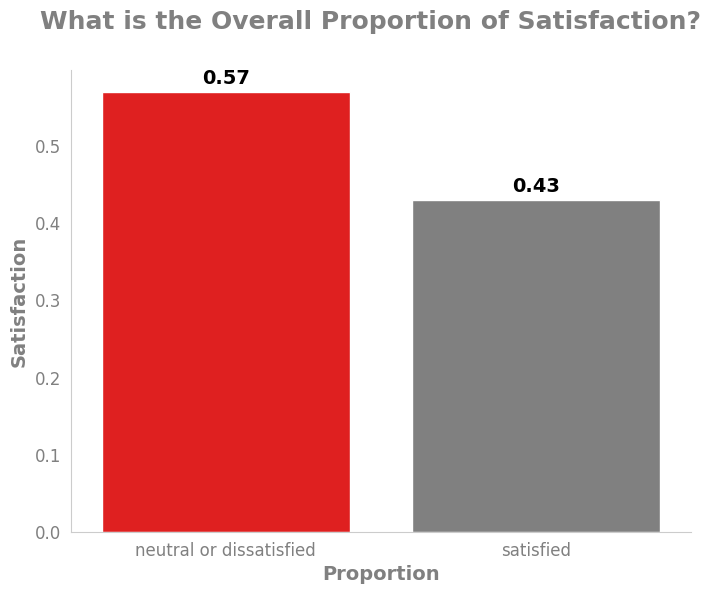

In [22]:
# what is the proportion of Satisfied and dissatisfied customer?

proportion = (
    train_df3
    .groupby('satisfaction')
    .agg({'id':'count'})
    .reset_index()
)

proportion['p'] = (proportion['id']/proportion['id'].sum()).round(2)

# rename the columns
proportion.columns = ['Satisfaction','Count Of Satisfaction','Proportion']

# viz the proportin
custom_colors = {
    'neutral or dissatisfied':'red',
    'satisfied':'grey'
}

plt.figure(
    figsize=(8,6)
)

p = sns.barplot(
    data=proportion,
    x='Satisfaction',
    y='Proportion',
    hue='Satisfaction',
    palette=custom_colors
);


# adjsut labels and title
adjust_viz(
    title="What is the Overall Proportion of Satisfaction?",
    x_label="Proportion",
    y_label="Satisfaction",
    obj=p,
    label_on=True
)



**Notes**

It appears that we have a high proportion of "Neutral or Dissatisfied" customers, which suggests that this Airline does not take good care of their customers. However, we need to test the reliability of these values by calculating the Standard Error

Standard Error - This is simply the Standard Deviation of the sampling distribution.

In [23]:
# run a SE calculation where SE for proportion = sqrt(p(1-p)/n)
success_p = 0.57
sample_n = len(train_df3)

sample_variation = np.sqrt((success_p*(1-success_p))/sample_n)

# show results
SE = round(sample_variation*100,2)
print(f"The SE: {SE}%")

# can we use a Binomial Distribution n*p >=10 and n*(1-p)>=10
print(f"Success/Failure Condition {sample_n*success_p:.0f}")
print(f"Success/Failure Condition {sample_n*(1-success_p):.0f}")

# calculate the confience interval to give us an idea as to where the proportions may lie in the test set
print(f"The 95% Confidence Interval MOE: +/- {1.96*SE:.2f}%") 
print(f"The Upper 95% Confidence Interval: {success_p*100 + 1.96*SE:.2f}%") 
print(f"The Lower 95% Confidence Interval: {success_p*100 - 1.96*SE:.2f}%") 
print(f"The sampled proportion: {success_p*100:.2f}%")

The SE: 0.15%
Success/Failure Condition 59225
Success/Failure Condition 44679
The 95% Confidence Interval MOE: +/- 0.29%
The Upper 95% Confidence Interval: 57.29%
The Lower 95% Confidence Interval: 56.71%
The sampled proportion: 57.00%


**Notes**

1. We have a reliable Proportion estimate for our sample due to the significantly small SE.
2. I can expect the true population proportion to lie between +/- 0.29% 95 out of 100 CI calculations. This means that I can say with 95% Confidence that the test proportion will sit somewhere between 56.71% & 57.29%.
3. The results also suggest that if this Airline transports 100 customers, 56 to 57 of them will be neutral or dissatisfied.

In [24]:
# Lets look at the other categoric features

for col in train_df.select_dtypes(include=['object']).columns:
    print(" " *30)
    print(train_df3[col].value_counts(normalize=True))


                              
Gender
Female    0.507459
Male      0.492541
Name: proportion, dtype: float64
                              
Customer Type
Loyal Customer       0.817322
disloyal Customer    0.182678
Name: proportion, dtype: float64
                              
Type of Travel
Business travel    0.689627
Personal Travel    0.310373
Name: proportion, dtype: float64
                              
Class
Business    0.477989
Eco         0.449886
Eco Plus    0.072124
Name: proportion, dtype: float64
                              
satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333
Name: proportion, dtype: float64


**Notes**

1. This Airline has a huge proportion of loyal customers - **82%**
2. Their customerbase mainly consists of Female customers - **51%**
3. Their highest selling flight type is Business - **48%**

In [25]:
# lets quickly describe the remaining features with .describe()

train_df3.select_dtypes(exclude=['object']).describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.245019
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.802830
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


**Notes**
1. By using the emprical rule, I can state that the Airline customer age range is as follows:
   * 68% of customer age is between 24 and 54 years old (+/- 1 Standard Deviation from the Mean)
   * 95% of the customer age range is between 9 and 69 years old (+/- 2 Standard Deviation from the Mean)
   * 99.7% of the customer age range is between 0 and 84 years old (+/- 3 Standard Deviation from the Mean)
2. The age range suggests a more mature audience, which is not surprising due to the high proportion of business class customers - suggests business people are their main target audience.
3. Inflight Service and Baggage Handling look to have the highest average rating (this is only based off a quick mean calculation - further analysis is required to confirm such a statement).
4. Delay in arrival appears to have a larger average than delay in departure (again, this is a quick analysis and not a Statistical confirmation. Further analysis required)

In [26]:
"""
What did customers rate in each satisfaction group?
"""
sat_grp = train_df3.groupby('satisfaction')

for i in train_df3.select_dtypes(include='int64').columns:
    if train_df3[i].max()<=5:
        print("*"*80)
        print(i)
        print(sat_grp[i].describe().reset_index())
        print("*"*80)


********************************************************************************
Inflight wifi service
              satisfaction    count      mean       std  min  25%  50%  75%  \
0  neutral or dissatisfied  58879.0  2.399633  0.964348  0.0  2.0  2.0  3.0   
1                satisfied  45025.0  3.161288  1.588697  0.0  2.0  4.0  5.0   

   max  
0  5.0  
1  5.0  
********************************************************************************
********************************************************************************
Departure/Arrival time convenient
              satisfaction    count      mean       std  min  25%  50%  75%  \
0  neutral or dissatisfied  58879.0  3.129112  1.500368  0.0  2.0  3.0  4.0   
1                satisfied  45025.0  2.970305  1.552213  0.0  2.0  3.0  4.0   

   max  
0  5.0  
1  5.0  
********************************************************************************
********************************************************************************
Ease of O

Poorly Rated Cleanliness Mean: 79
Poorly Rated Cleanliness Stdev: 4
Excellently Rated Mean: 43
Excellently Rated Stdev: 5


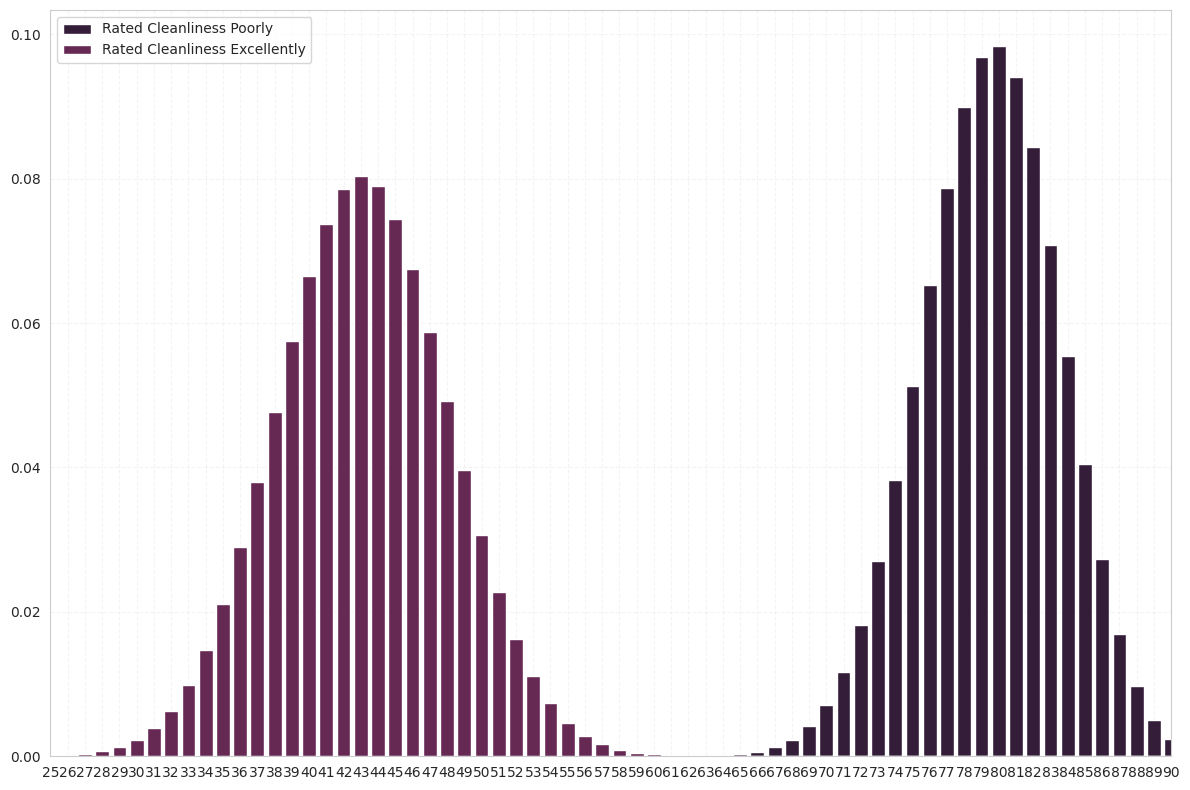

In [27]:
"""
By applying a Binomial Distribution, lets compare the distributions of high
and low scoring rating for:

1. Cleanliness
2. Leg Room Service
"""

binom_dist = stats.binom
n_trials = 100

#split the groups :
# group a rated 2 or less
# group b rated 4 or more

grpA_mask = train_df3['Cleanliness'] <= 2
group_a = train_df3.loc[grpA_mask].copy()

grpB_mask = train_df3['Cleanliness'] >= 4
group_b = train_df3.loc[grpB_mask].copy()


# calculate the propportions -> success and failures
group_a_agg = (
    group_a['satisfaction']
    .value_counts(normalize=True)
    .reset_index()
)
group_b_agg = (
    group_b['satisfaction']
    .value_counts(normalize=True)
    .reset_index()
)

# as we are interested in unhappy customers, lets get their proportions
unhappy_group_a = group_a_agg['satisfaction']=='neutral or dissatisfied'
group_a_p = group_a_agg['proportion'].loc[unhappy_group_a].values[0]

unhappy_group_b = group_b_agg['satisfaction']=='neutral or dissatisfied'
group_b_p = group_b_agg['proportion'].loc[unhappy_group_b].values[0]


# now to fit a Binomial Distribution
x_val = range(0,100,1)
fitted_binom_grpA = binom_dist.pmf(k=x_val,n=n_trials,p=group_a_p)
fitted_binom_grpB = binom_dist.pmf(k=x_val,n=n_trials,p=group_b_p)

# print out key overview stats
grp_a_stats = binom_dist.stats(n=n_trials,p=group_a_p,moments=(['m','v']))
grp_b_stats = binom_dist.stats(n=n_trials,p=group_b_p,moments=(['m','v']))


print(f"Poorly Rated Cleanliness Mean: {grp_a_stats[0]:.0f}\nPoorly Rated Cleanliness Stdev: {np.sqrt(grp_a_stats[1]):.0f}")
print(f"Excellently Rated Mean: {grp_b_stats[0]:.0f}\nExcellently Rated Stdev: {np.sqrt(grp_b_stats[1]):.0f}")


# viz the resultss and compare
plt.figure(
    figsize=(12,8)
)
sns.barplot(
    x=x_val,
    y=fitted_binom_grpA,
    label='Rated Cleanliness Poorly'
)

sns.barplot(
    x=x_val,
    y=fitted_binom_grpB,
    label='Rated Cleanliness Excellently'
)

plt.xlim(25,90)
plt.grid(
    linestyle='--',
    alpha=0.2
)
plt.tight_layout()

**Notes**

Based on modelling the data with the Binomial Distribution, the following observations were made:

1. Cleanliness rating appears to provide strong signal for the ML model due to the expected number of dissatisfied customers who rated this area poorly. In the modelling phase, I suspect that this feature will appear as a highly weighted feature because of this.
2. The number of expected dissatisfied customers in both groups per 100 customers is rather high (43 and 79 customer), suggesting that there are other variables to consider that influence customer satisfaction levels.
3. The Airline should focus on identifying why these customers rated cleanliness so low and rectify the situation.

In [28]:
group_a_p

np.float64(0.7946846785690042)

In [29]:
train_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Unnamed: 0                         103904 non-null  int64   
 1   id                                 103904 non-null  int64   
 2   Gender                             103904 non-null  object  
 3   Customer Type                      103904 non-null  object  
 4   Age                                103904 non-null  int64   
 5   Type of Travel                     103904 non-null  object  
 6   Class                              103904 non-null  object  
 7   Flight Distance                    103904 non-null  int64   
 8   Inflight wifi service              103904 non-null  int64   
 9   Departure/Arrival time convenient  103904 non-null  int64   
 10  Ease of Online booking             103904 non-null  int64   
 11  Gate location             

## Does flight distance influence customer satisfaction? (The psychological toll of long-haul travel in a confined space can be exhausting).

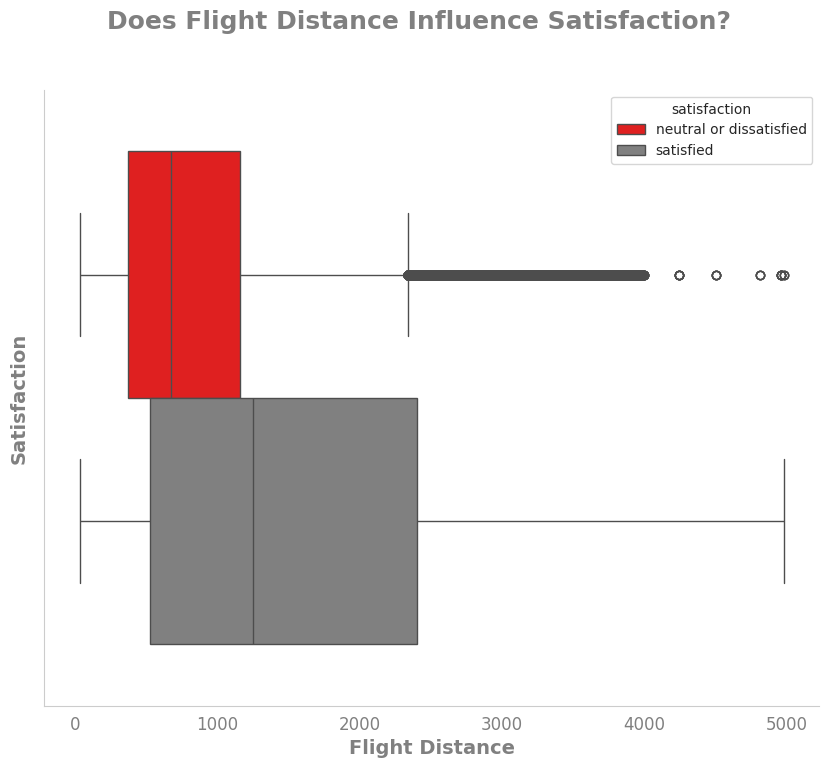

In [30]:
# lets review the data in a boxplot by satisfaction

custom_colors = {
    'neutral or dissatisfied':'red',
    'satisfied':'grey'
}

plt.figure(
    figsize=(10,8)
)

distance_sat = sns.boxplot(
    data=train_df3,
    x='Flight Distance',
    hue='satisfaction',
    palette=custom_colors
)

# adjsut labels and title
adjust_viz(
    title="Does Flight Distance Influence Satisfaction?",
    x_label="Flight Distance",
    y_label="Satisfaction",
    obj=distance_sat
)

T-Statistic: 96.4236
P-Value: 0.0000
Effect Size (Cohen's d): 0.6318

Result: Reject the Null Hypothesis.
There is statistical evidence that unsatisfied customers fly shorter distances.


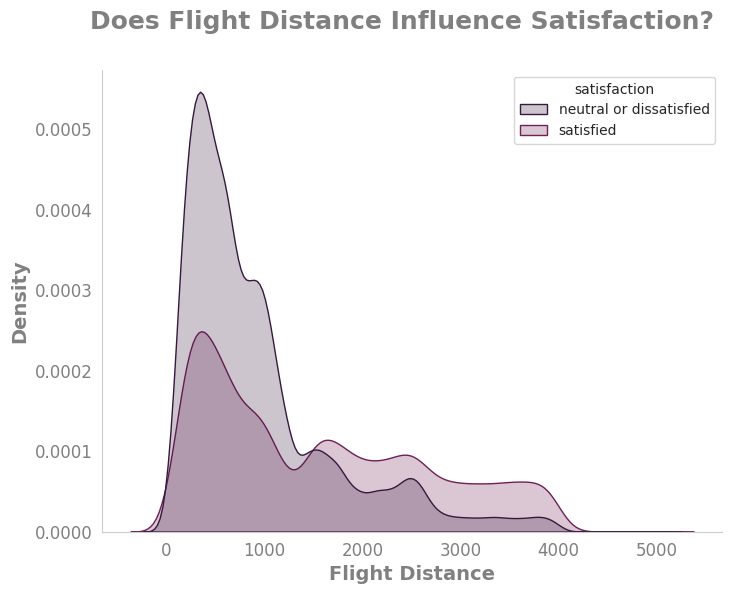

In [31]:
"""
lets conduct a hypothesis test to compare the means of the two groups.
However, assumptions must be met to conduct a t or z two-sample test

1. Is the population variance known?

It is unknown as we don't know if this sample is there entire dataset or just a sample.

2. Is the data Normally Distributed?

We can use Central Limit Theorem (CLT) as our sample size (n)>30. I can do this because CLT states that a given test statistic (our mean flight distance) 
is sampled from an Approximately Normal Distribution of the mean, given that n is large enough.

3. Are the two samples independent?

We can assume independece as each customers satisfaction will not influence another, unless each customer are on the same flight which we cannot verify.

I will use the student t-test because of the above responses.

"""

satisfied_customers = train_df3['Flight Distance'].loc[train_df3['satisfaction']=='satisfied'].copy()
unsatisfied_customers = train_df3['Flight Distance'].loc[train_df3['satisfaction']!='satisfied'].copy()

# h0: Average Flight Distance for Satisfied Customers = Average Flight Distance for Unsatisfied Customers
# h1: Average Flight Distance for Satisfied Customers > Average Flight Distance for Unsatisfied Customers

# run t-test
alpha = 0.05
t_stat, p_value = stats.ttest_ind(
    satisfied_customers,
    unsatisfied_customers, 
    equal_var=False, # we assume the pop variance is unequal for both samples
    alternative='greater' # This directly matches the ">" in h1
)

# calculate cohen's d for effect size (mean_a-mean_b)/s_pooled
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pool_std = (((nx - 1) * x.var() + (ny - 1) * y.var()) / dof) ** 0.5
    return (x.mean() - y.mean()) / pool_std

d = cohen_d(satisfied_customers,unsatisfied_customers)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Effect Size (Cohen's d): {d:.4f}")


# show results
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("There is statistical evidence that unsatisfied customers fly shorter distances.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("No statistical evidence that unsatisfied customers fly shorter distances.")


# viz the results as a quick comparison

plt.figure(
    figsize=(8,6)
)


ax = sns.kdeplot(
    data=train_df3,
    x='Flight Distance',
    hue='satisfaction',
    fill=True
);

# adjsut labels and title

adjust_viz(
    title="Does Flight Distance Influence Satisfaction?",
    x_label="Flight Distance",
    y_label="Density",
    obj=ax
)

**Notes**

It appears satisfied customers tend to fly longer distances than their neutral or dissatisfied counterparts, providing statistically significant evdience that longer distance does not lead to unhappy customers. In fact, mean flight distance of satisfied customers is 0.63 standard deviations away from their counterpart mean, evidencing a medium effect size. Therefore, I can conclude that I have statistically significant evidence to suggest that longer flight distance results in better customer satisfaction. However, there will be other factors influencing this outcome than just the distance such as in-flight services which must be explored.

From a business point of view, this tells me that the longer distance flights are poentially providing higher value to customers which leads to higher satisfaction rates. Such hypothesis leads to the following questions:

1. How did longer distance flights score in in-flight their services?
2. How did longer distance flights score in their pre- and out of flight services?

### Feature Engineering - Flight Distance Type

/tmp/ipykernel_57/2704210046.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df4.groupby('DistanceType')['satisfaction']


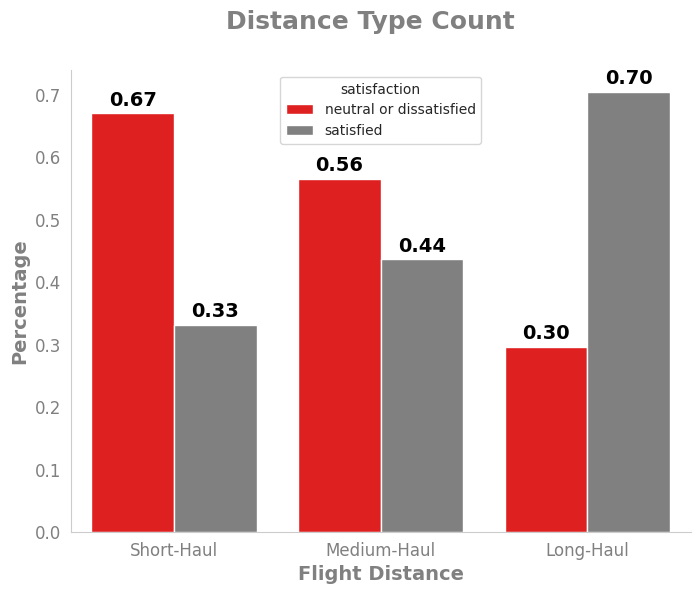

In [32]:
def flight_distance_type(df):
       
    # Define bins and labels
    bins = [0, 800, 2200, df['Flight Distance'].max()]
    labels = ['Short-Haul', 'Medium-Haul', 'Long-Haul']

    # Create the new feature
    df['DistanceType'] = pd.cut(df['Flight Distance'], bins=bins, labels=labels)

    return df

# apply to train and test
train_df4,test_df4 = flight_distance_type(train_df3),flight_distance_type(test_df3)

agg4 = (
    train_df4.groupby('DistanceType')['satisfaction']
    .value_counts(normalize=True)
    .reset_index(name='percentage')
    .sort_values(by=['DistanceType', 'satisfaction'])
)


# viz
plt.figure(
    figsize=(8,6)
)

custom_colors = {
    'neutral or dissatisfied':'red',
    'satisfied':'grey'
}

# verify the work
ax = sns.barplot(
    data=agg4,
    x='DistanceType',
    y='percentage',
    hue='satisfaction',
    palette=custom_colors
    
);

adjust_viz(
    title="Distance Type Count",
    x_label="Flight Distance",
    y_label="Percentage",
    obj=ax,
    label_on=True
)

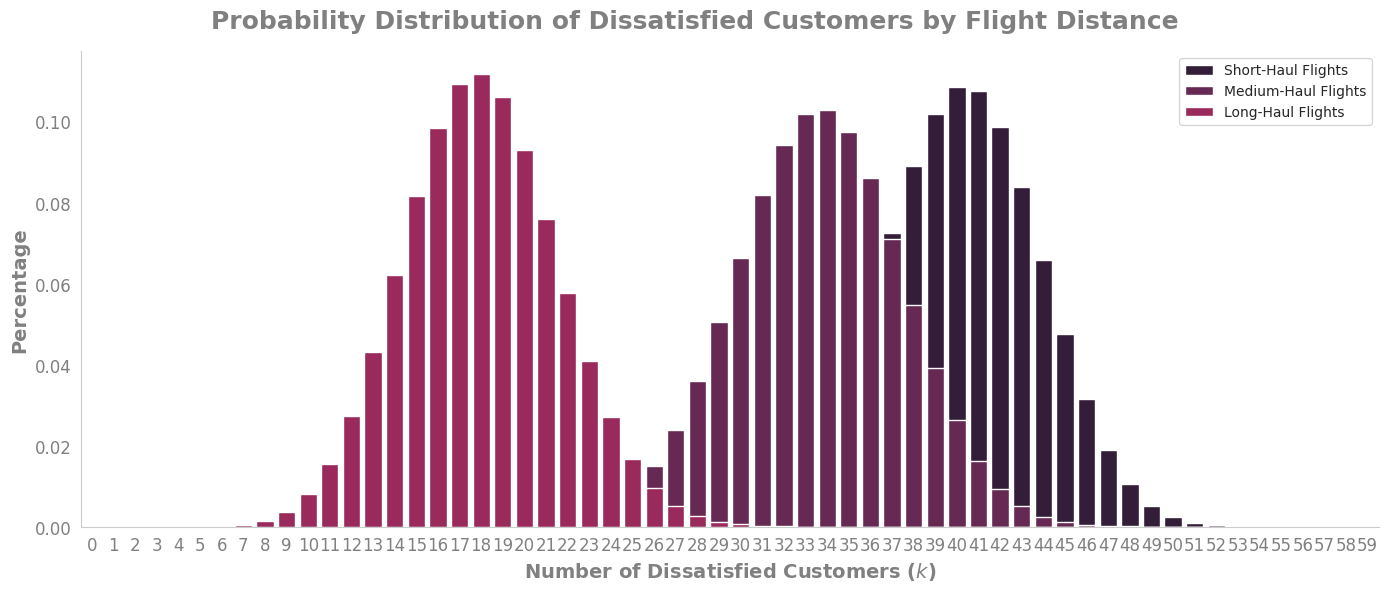

In [33]:
"""
let's use the Binomial Distribution to show each groups probability of being dissatisfied with the Aurline.

Like with most Statistical tools, there are assumptions that must be met:

1. There are two outcomes 

    Yes - Satissfied and Dissatisfied/neutral

2. The trials are independent

    We can assume independence as each customers has their own opnion on the airline service.
    We also do not know if the data contains flights where some customers are grouped together.
    If this contains data of similar flights, then I must acknowledge external factors such as flight delays
    influence multiple responeses.

3. The probability of p is constant for each trial

    We can assume this for each trial for each group with the values stated above.

4. There are a set amout of trials

    Yes - there will be 75 trials
    
"""

# lets run the expeirment

# get the probabilities
sh_p = 0.67
mh_p = 0.56
lh_p = 0.3

# trial size
n_trials = 60

# x values for viz
x = np.arange(0,n_trials)

# fit the binomial dist
sh_binom = stats.binom.pmf(x,n_trials,sh_p)
mh_binom = stats.binom.pmf(x,n_trials,mh_p)
lh_binom = stats.binom.pmf(x,n_trials,lh_p)

plt.figure(
    figsize=(14,6)
)

ax = sns.barplot(
    x=x,
    y=sh_binom,
    label="Short-Haul Flights"
);

ax = sns.barplot(
    x=x,
    y=mh_binom,
    label="Medium-Haul Flights"
);

ax = sns.barplot(
    x=x,
    y=lh_binom,
    label="Long-Haul Flights"
);

adjust_viz(
    title="Probability Distribution of Dissatisfied Customers by Flight Distance",
    x_label="Number of Dissatisfied Customers ($k$)",
    y_label="Percentage",
    obj=ax,
    label_on=False
)

plt.tight_layout();
plt.legend();

**Notes**

By using the Binomial Distribution I have successfully visualised the number of dissatisfied customers by the flight distance type, where you can clearly see an overlap on Medium- and Short-Haul flights. However, we have a peak on Short-Haul flights at 40 customers, which means if i take a random sample of 60 customers, there is a ~11% probability that 40 customers will be dissatisfied.

On the other hand, Long-Haul customers are generally happier compared to the other flights as the peak is at 18 customers with a probability of ~11%. Could this be because longer distanced flight contain more luxury services to accomodate for this?

From a Business persective, this tells me that the Airline is failing on the Short- and Medium-Haul flights, as this is where the customers seem to be the most dissatisfied based on the above Distribution and the previous barchart.

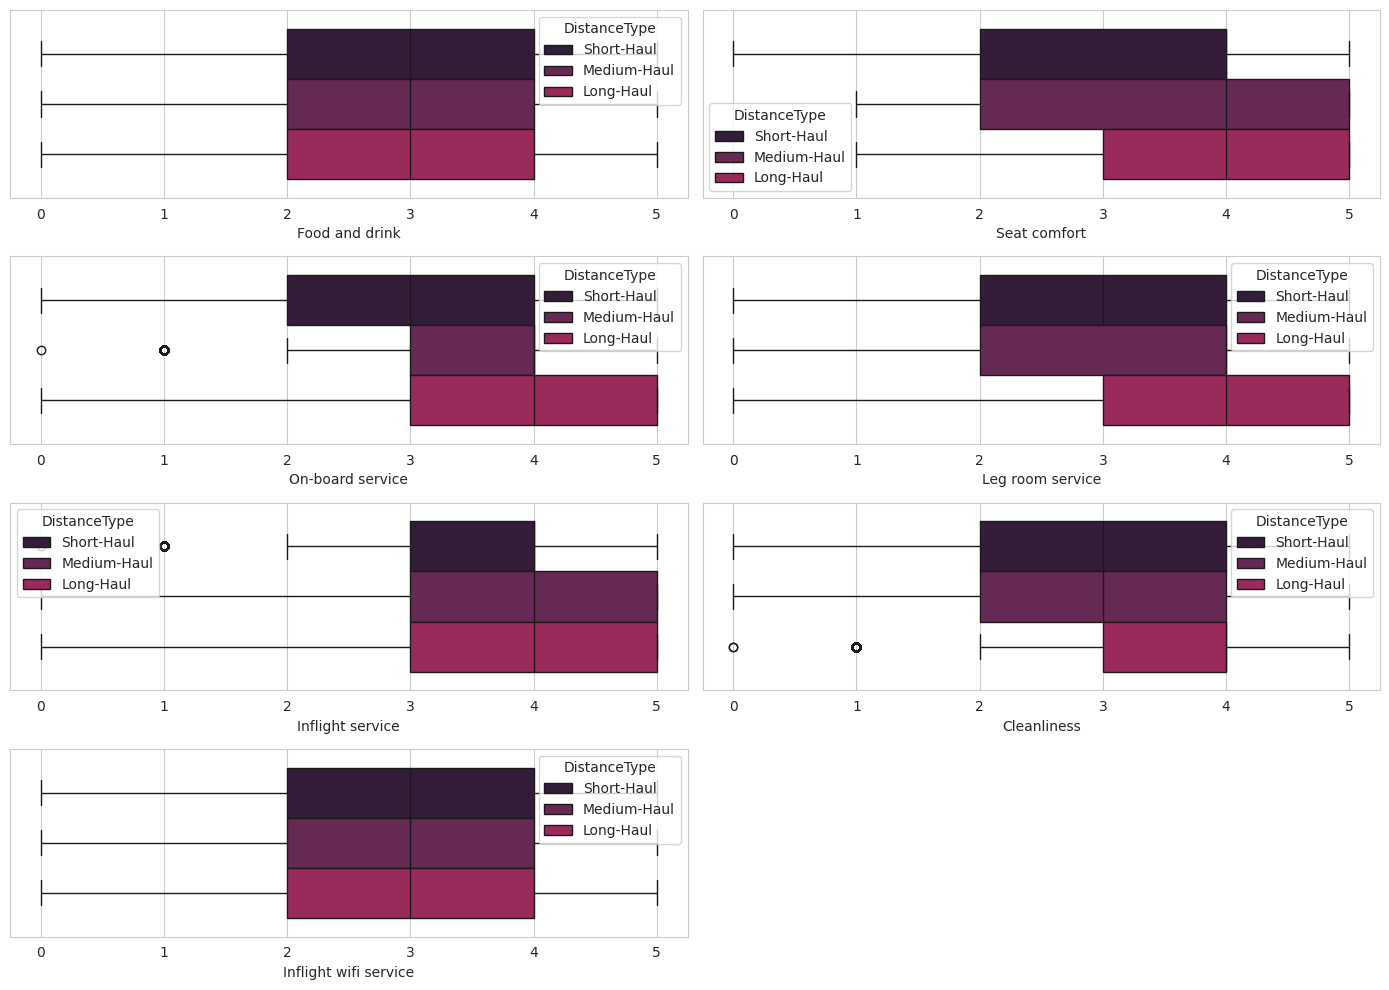

In [34]:
"""
Now we know where the lion's share of the problem lie, lets review the inflight service to see if these scored lower in short and medium haul
flights.

The reason for doing this is to identify operatinal improvements for the airline to improve customer satisfaction.

services to analyse
1. Food and drink
2. Seat comfort
3. On-board service
4. Leg room service
5. Inflight service
6. Cleanliness
7. Inflight wifi service
"""
services = [
    'Food and drink',
    'Seat comfort',
    'On-board service',
    'Leg room service',
    'Inflight service',
    'Cleanliness',
    'Inflight wifi service'
    
]

row = 2
col = 4

# show stats overview
fig, axes = plt.subplots(
    col,row,figsize=(14,10)
)

# loop thorugh each service and viz the distribution of their scores
feature = 0
for i in range(col):
    for j in range(row):
        # control flow so we don't exceed the 7 variable list
        if feature < len(services):
            sns.boxplot(
                data=train_df4,
                x=services[feature],
                ax=axes[i,j],
                hue='DistanceType'
            )
            feature+=1
            
            
        else:
           # remove last axis
            axes[i, j].axis('off')
            
            

plt.tight_layout()

**Notes**

Based on the above boxplots, I should focus on the following features because of their distrbutions:

1. Cleanliness
2. Seat Comfort
3. On-Board Service

The remaining either showed little to no difference or the variables are too costly to improve such as leg room, as this is dependent of the size of the plane.

In [35]:
# conduct hypthesis test on whether short-haul average score is less than long haul flights
train_df4.groupby(['DistanceType','satisfaction'])['Cleanliness'].describe()

/tmp/ipykernel_57/3223650363.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df4.groupby(['DistanceType','satisfaction'])['Cleanliness'].describe()


count      mean       std  min  25%  \
DistanceType satisfaction                                                     
Short-Haul   neutral or dissatisfied  33526.0  2.980523  1.335572  0.0  2.0   
             satisfied                16556.0  3.624426  1.231537  1.0  3.0   
Medium-Haul  neutral or dissatisfied  19823.0  2.941936  1.329337  0.0  2.0   
             satisfied                15307.0  3.768864  1.119545  1.0  3.0   
Long-Haul    neutral or dissatisfied   5530.0  2.646112  1.214583  0.0  2.0   
             satisfied                13162.0  3.866662  1.031640  1.0  3.0   

                                      50%  75%  max  
DistanceType satisfaction                            
Short-Haul   neutral or dissatisfied  3.0  4.0  5.0  
             satisfied                4.0  5.0  5.0  
Medium-Haul  neutral or dissatisfied  3.0  4.0  5.0  
             satisfied                4.0  5.0  5.0  
Long-Haul    neutral or dissatisfied  3.0  4.0  5.0  
             satisfied                4.0  5.0  5.0

In [36]:
"""
The question I am looking to answer is:

Are customers who were labelled as neutral or dissatisfied rate cleanliness lower on short-haul flights than long haul?

We can set up our test as follows:

H0: Mean Cleanliness Score for neutral or dissatisfied on long-haul flights = Mean Cleanliness Score for neutral or dissatisfied on short-haul flights
H1: Mean Cleanliness Score for neutral or dissatisfied on long-haul flights > Mean Cleanliness Score for neutral or dissatisfied on short-haul flights

the assumptions of our data:

1. We do not know the population variance.
2. We can assume Normally Distributed data due to n>30 - CLT
3. Our Variances in both groups are not equal
4. We assume that each response are independent as we do not know the data contains customers from the same flight.

Based on the above, I will use a two sample t-test
"""


# create the two samples

short_haul = (train_df4['DistanceType']=='Short-Haul')&(train_df4['satisfaction']=='neutral or dissatisfied')
long_haul = (train_df4['DistanceType']=='Long-Haul')&(train_df4['satisfaction']=='neutral or dissatisfied')

sh_sample = train_df4['Cleanliness'].loc[short_haul].copy()
lh_sample = train_df4['Cleanliness'].loc[long_haul].copy()

def ttest_sample(sample_a,sample_b,test_type,equal_variance=False):   
    # conduct the test
    alpha = 0.05 
    t_stat, p_value = stats.ttest_ind(
        sample_a,
        sample_b,
        equal_var=equal_variance,
        alternative=test_type
    )
    
    # conduct effect size analysis
    d = cohen_d(sample_a,sample_b)
    
    print(f"T-Statistic: {t_stat:.4f}")
    print(f"P-Value: {p_value:.4f}")
    print(f"Effect Size (Cohen's d): {d:.4f}")
    
    # return results
    if p_value<=alpha:
        print("We have enough evidence to reject H0. Short-Haul flights are typically rated less than Long-Haul flights")
    else:
        print("There is little evidence to reject H0, suggesting what we have observed is likely to sample variance")


# run the test
ttest_sample(
    sample_a=sh_sample,
    sample_b=lh_sample,
    test_type='less'
)

T-Statistic: 18.6950
P-Value: 1.0000
Effect Size (Cohen's d): 0.2535
There is little evidence to reject H0, suggesting what we have observed is likely to sample variance


**Notes**

Our results suggests that there is no evidence answer our question of dissatisfied customers rated cleanliness less on short-haul flights than long-haul. For the airline, it provides evidence that their problems do not lie within their cleaning processes.

Based on the p-value and our test type, it tells me that Short-Haul flights are, on average, rated higher amoung dissatisfied customers which is a win for the Airline. However, to play devil's advocate, are these customers rating the flight based on when they go on board the plane or when they leave? This is important as once customers are on the plane, they will have consumed inflight goods and create a mess, which might be what they're basing their review on.

T-Statistic: 6.2442
P-Value: 1.0000
Effect Size (Cohen's d): 0.0784
There is little evidence to reject H0, suggesting what we have observed is likely to sample variance


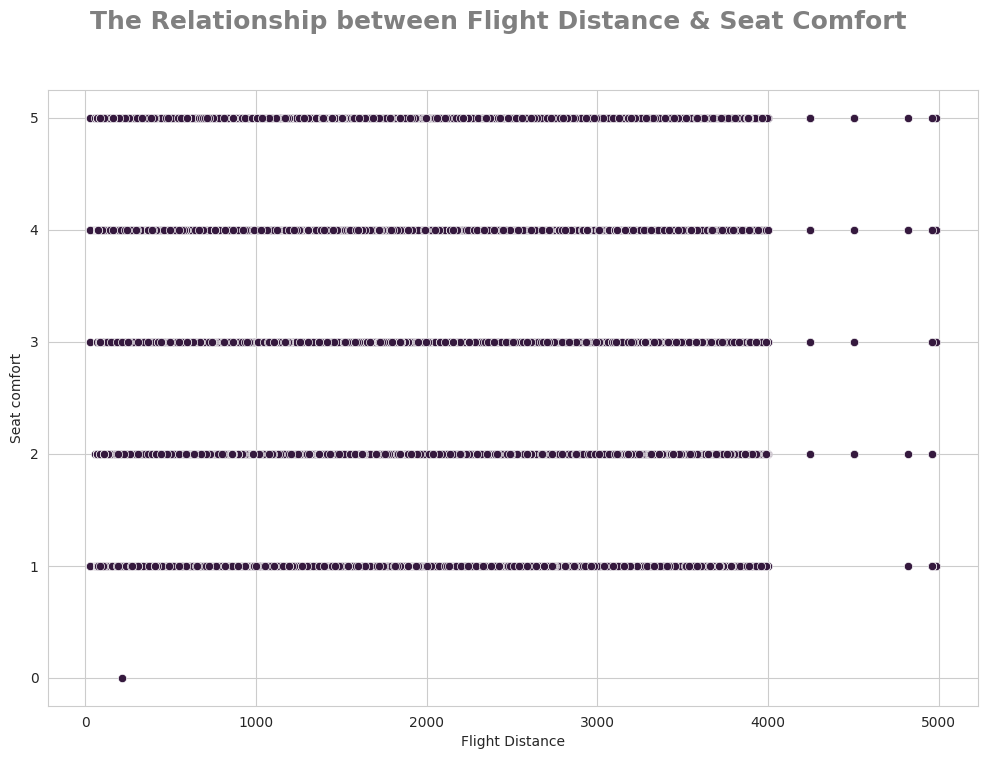

In [37]:
"""
Now we do the same for seat comfort.

We can set up our test as follows:

H0: Mean Seat Comfort Score for neutral or dissatisfied on long-haul flights = Mean Seat Comfort Score  for neutral or dissatisfied on short-haul flights
H1: Mean Seat Comfort Score for neutral or dissatisfied on long-haul flights > MeanSeat Comfort Score for neutral or dissatisfied on short-haul flights
"""

# create the two samples

short_haul = (train_df4['DistanceType']=='Short-Haul')&(train_df4['satisfaction']=='neutral or dissatisfied')
long_haul = (train_df4['DistanceType']=='Long-Haul')&(train_df4['satisfaction']=='neutral or dissatisfied')

sh_sample = train_df4['Seat comfort'].loc[short_haul].copy()
lh_sample = train_df4['Seat comfort'].loc[long_haul].copy()

# run the test
ttest_sample(
    sample_a=sh_sample,
    sample_b=lh_sample,
    test_type='less'
)


# show results
plt.figure(
    figsize=(12,8)
)

sns.scatterplot(
    data=train_df4,
    x='Flight Distance',
    y='Seat comfort'
)

adjust_viz(
    title="The Relationship between Flight Distance & Seat Comfort",
    x_label="Flight Distance",
    y_label="Seat Comfort",
    obj=ax,
    label_on=False
)

**Notes**

It appears that we have the same result where the evidence does not support the rejection of the Null hypothesis for a left-tailed test, but the evidence suggests that mean Seat Comfort score is statistically greater for Short-Haul flights than Long-Haul!

In [38]:
"""
Now we do the same for seat comfort.

We can set up our test as follows:

H0: Mean Seat Comfort Score for neutral or dissatisfied on long-haul flights = Mean Seat Comfort Score  for neutral or dissatisfied on short-haul flights
H1: Mean Seat Comfort Score for neutral or dissatisfied on long-haul flights > MeanSeat Comfort Score for neutral or dissatisfied on short-haul flights
"""

# create the two samples

short_haul = (train_df4['DistanceType']=='Short-Haul')&(train_df4['satisfaction']=='neutral or dissatisfied')
long_haul = (train_df4['DistanceType']=='Long-Haul')&(train_df4['satisfaction']=='neutral or dissatisfied')

sh_sample = train_df4['On-board service'].loc[short_haul].copy()
lh_sample = train_df4['On-board service'].loc[long_haul].copy()

# run the test
ttest_sample(
    sample_a=sh_sample,
    sample_b=lh_sample,
    test_type='less'
)

T-Statistic: 21.0701
P-Value: 1.0000
Effect Size (Cohen's d): 0.2895
There is little evidence to reject H0, suggesting what we have observed is likely to sample variance


**Notes**

Although we saw that Long-Haul customers were generally more satisfied with the Airline services, we observed results that countered my initial understanding of the data. Although the Hypothesis tests returned small to medium effect sizes, suggesting small to medium differences in the mean values by samples, we saw that those who were dissatisfied with the Airline concerning On-Board Service, Seat Comfort and Cleanliness, Long-Haul Flights were observed as typically rating these services less.

To translate this into a business action, the Airline should concentrate on the following actions to reduce dissatisfaction in their customer base:

1. Improve On-Board Service for customers on Long-Haul Flights by upskilling staff members to better handle and serve customers. Moreover, improve guidelines for staff members so that customers feel like they are being attended to, such as improving the frequency and regularity of service by staff members and clear communication of delay reasoning with consistent updates.

2. Seat Comfort is a variable that is arguably out of control for Airlines, but they can offer alternatives to improve comfort levels such as flight cushions that customers could use.

3. Cleanliness must be improved for the passengers by enabling the staff to survey the plane before passengers arrive. Make this a priority and mandatory process and any waste located on the plane must be disposed of appropriately. Moreover, investing in an improved cleaning company is also advised to improve this area of service.

One critical point to identify for this analysis is that the distance could be impacting customer scores as with any long distance journey, we can be emotionally charged to give lower scores than normal. Conversely, ensuring cleanliness on the plane by regular waste cleaning trips may improve customer perception of the Airline!

In [39]:
train_df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Unnamed: 0                         103904 non-null  int64   
 1   id                                 103904 non-null  int64   
 2   Gender                             103904 non-null  object  
 3   Customer Type                      103904 non-null  object  
 4   Age                                103904 non-null  int64   
 5   Type of Travel                     103904 non-null  object  
 6   Class                              103904 non-null  object  
 7   Flight Distance                    103904 non-null  int64   
 8   Inflight wifi service              103904 non-null  int64   
 9   Departure/Arrival time convenient  103904 non-null  int64   
 10  Ease of Online booking             103904 non-null  int64   
 11  Gate location             

## Do departure and arrival delays influence customer satisfaction? If so, which variable carries the most weight?

## How is customer satisfaction influenced by departure and arrival delay?

In this section, I will apply the Binomal Distribution to visualise the value of this feature. I will group the customers by the following

1. 1-29 Minutes
2. 30-59 Minutes
3. 60-119 Minutes
4. 120 Minutes +

I will also use the Beta Distribution to model the proportion in its reliability, but also apply some Baysian techniques to see if we can calculate P(customer is unhappy|wait time is n minutes)


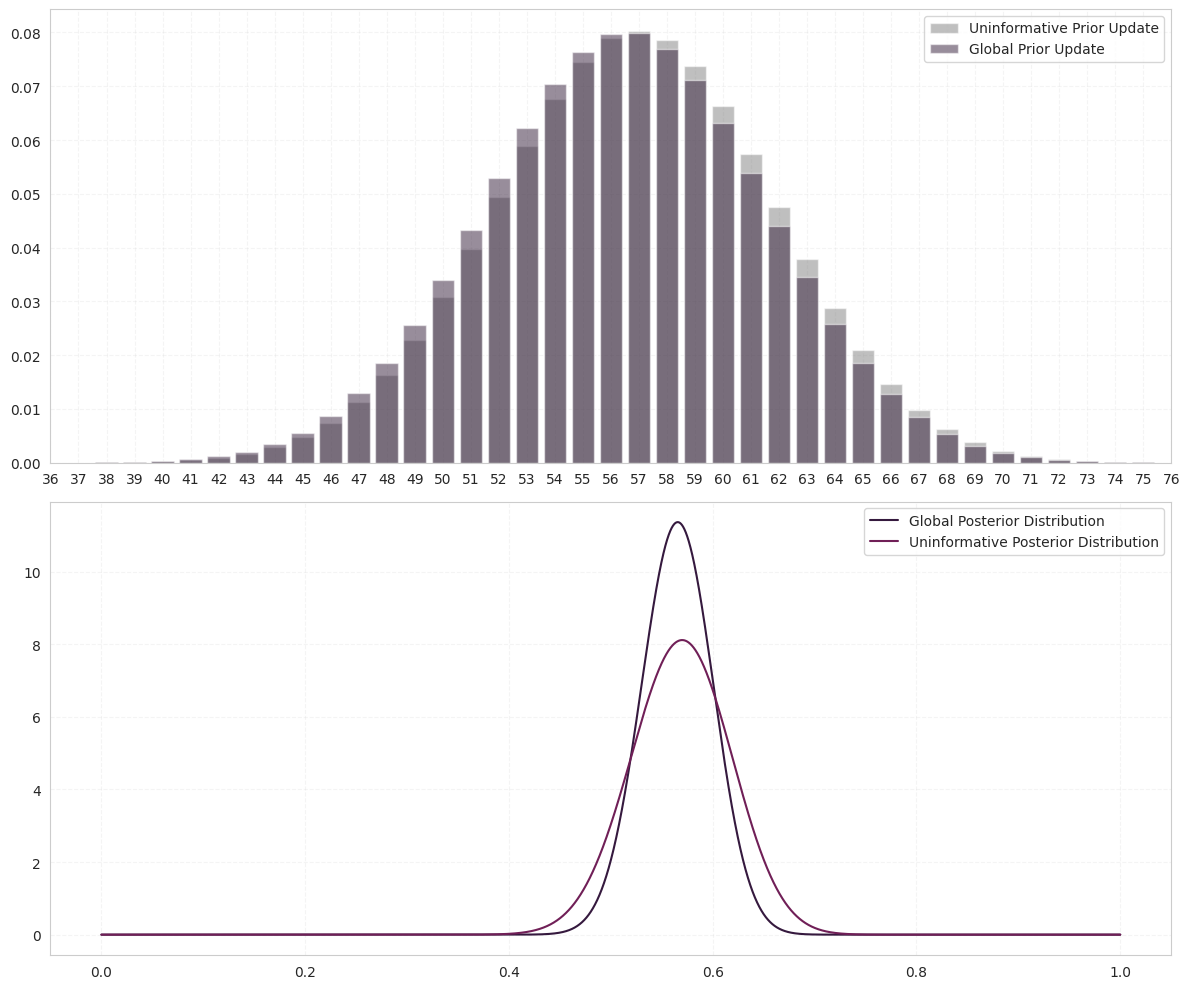

In [40]:
"""
As I have alreadt established the assumptions of the Binomial, I won't do so here. However, for my prior I will use an uninformative prior & the golbal dissatisfaction
in order to compare the impact of the completely different prioirs. Lets experiment!

'1-30 Minutes'
'30-60 Minutes'
'60-120 Minutes'
'120 Minutes +'
"""
binom_dist = stats.binom
beta_dist = stats.beta

# =================================================================================
#                             The Prior set up
# =================================================================================
# calculate the priors
uninformative_prior_alpha = 1 # success (dissatisfaction)
uninformative_prior_beta = 1 # failure (satisfied)

# we are using a small sample size so that we are not using a super strong prior, hence not using the entire sample.
# if we used the entire sample, we woud have a really strong Prior which makes an overconfident distribution
prior_sample_size = 100

global_prior = (
    train_df4['satisfaction']
    .value_counts(normalize=True)
    .reset_index()
)

# get alpha and beta
alpha = global_prior['satisfaction']=='neutral or dissatisfied'
global_alpha = int(global_prior['proportion'].loc[alpha].iloc[0] * prior_sample_size)
global_beta = prior_sample_size-global_alpha

# sample the groups
first_group = train_df4.loc[train_df4['DepartureDelayBuckets']=='1-30 Minutes'].copy()
first_group_n = len(first_group)

# calculate the alpha and beta for group. 
pass_fail = (
    first_group['satisfaction']
    .value_counts(normalize=True)
    .reset_index()
)

mask = pass_fail['satisfaction']=='neutral or dissatisfied'
group_alpha = int(pass_fail['proportion'].loc[mask].values[0] * prior_sample_size)
group_beta = prior_sample_size - group_alpha

# =================================================================================
#                             The Beta Distribution
# =================================================================================



x_vals = np.linspace(0,1,10000)
beta_dist_res = beta_dist.pdf(
    x=x_vals,
    a=(group_alpha+global_alpha),
    b=(group_beta+global_beta)
)

uninformative_beta_dist_res = beta_dist.pdf(
    x=x_vals,
    a=(group_alpha+uninformative_prior_alpha),
    b=(group_beta+uninformative_prior_beta)
)


# =================================================================================
#                             The Binomal Distribution
# =================================================================================

#extract the posterior distribution mean
uninformative_mean = beta_dist.mean(
    a=(group_alpha+uninformative_prior_alpha),
    b=(group_beta+uninformative_prior_beta)
)

global_prior_mean = beta_dist.mean(
    a= (group_alpha+global_alpha),
    b= (group_beta+global_beta)
)

n_trials = 100
binom_x = range(1,101,1)
uninformative_binomial_update = binom_dist.pmf(binom_x,n_trials,uninformative_mean)
global_prio_binomial_update = binom_dist.pmf(binom_x,n_trials,global_prior_mean)

# =================================================================================
#                             Show the results
# =================================================================================
fig,axes= plt.subplots(
    2,1,figsize=(12,10)
)

sns.barplot(
    x=binom_x,
    y=uninformative_binomial_update,
    ax=axes[0],
    label='Uninformative Prior Update',
    alpha=0.5,
    color='grey'
)

sns.barplot(
    x=binom_x,
    y=global_prio_binomial_update,
    ax=axes[0],
    label='Global Prior Update',
    alpha=0.5
)

axes[0].set_xlim(35,75)

sns.lineplot(
    x=x_vals,
    y=beta_dist_res,
    label='Global Posterior Distribution',
    ax=axes[1]
)
sns.lineplot(
    x=x_vals,
    y=uninformative_beta_dist_res,
    label='Uninformative Posterior Distribution',
    ax=axes[1]
)

for i in range(2):
    axes[i].grid(
        linestyle='--',
        alpha=0.2
    )

plt.tight_layout()

**Notes**

Based on the above results I have observed the follwoing:

1. The global Prior provides a Beta Distribution with a lesser variance in comparison to our Noninformative Prior. This means that our global prioir provides more information as to where the global proportion sits.
2. Whilst the global prior produces a posterior with lower variance — indicating greater certainty — the location of both posteriors is very similar. This suggests that the global dissatisfaction rate is close to the group-level rate for this wait band, meaning the choice of prior has little influence on where the posterior is centred in this instance.
3. The true proportion of dissatisfied customers appears to be centered around ~58% for this group of customers. I do need to compare against the other groups to see how it changes relative to delay time.
4. The lack lack of difference between the two Priors is visualised in the Beta-Binomial distribution where both groups almost completely overlap!

Based on our results above, I will use the global prior on all the groups and see how they differ!

In [41]:
def Baysian_Beta_Binom(prior_sample_size: int,Departure_delay: str):
    binom_dist = stats.binom
    beta_dist = stats.beta
    
    # =================================================================================
    #                             The Prior set up
    # =================================================================================
    # calculate the priors
    uninformative_prior_alpha = 1 # success (dissatisfaction)
    uninformative_prior_beta = 1 # failure (satisfied)
    
    # we are using a small sample size so that we are not using a super strong prior, hence not using the entire sample.
    # if we used the entire sample, we woud have a really strong Prior which makes an overconfident distribution
    
    global_prior = (
        train_df4['satisfaction']
        .value_counts(normalize=True)
        .reset_index()
    )
    
    # get alpha and beta
    alpha = global_prior['satisfaction']=='neutral or dissatisfied'
    global_alpha = int(global_prior['proportion'].loc[alpha].iloc[0] * prior_sample_size)
    global_beta = prior_sample_size-global_alpha
    
    # sample the groups
    first_group = train_df4.loc[train_df4['DepartureDelayBuckets']==Departure_delay].copy()
    first_group_n = len(first_group)
    
    # calculate the alpha and beta for group. 
    pass_fail = (
        first_group['satisfaction']
        .value_counts(normalize=True)
        .reset_index()
    )
    
    mask = pass_fail['satisfaction']=='neutral or dissatisfied'
    group_alpha = int(pass_fail['proportion'].loc[mask].values[0] * prior_sample_size)
    group_beta = prior_sample_size - group_alpha
    
    # =================================================================================
    #                             The Beta Distribution
    # =================================================================================
    
    
    
    x_vals = np.linspace(0,1,10000)
    beta_dist_res = beta_dist.pdf(
        x=x_vals,
        a=(group_alpha+global_alpha),
        b=(group_beta+global_beta)
    )
    
    uninformative_beta_dist_res = beta_dist.pdf(
        x=x_vals,
        a=(group_alpha+uninformative_prior_alpha),
        b=(group_beta+uninformative_prior_beta)
    )
    
    
    # =================================================================================
    #                             The Binomal Distribution
    # =================================================================================
    
    #extract the posterior distribution mean
    uninformative_mean = beta_dist.mean(
        a=(group_alpha+uninformative_prior_alpha),
        b=(group_beta+uninformative_prior_beta)
    )
    
    global_prior_mean = beta_dist.mean(
        a= (group_alpha+global_alpha),
        b= (group_beta+global_beta)
    )
    
    n_trials = 100
    binom_x = range(0,101,1)
    uninformative_binomial_update = binom_dist.pmf(binom_x,n_trials,uninformative_mean)
    global_prio_binomial_update = binom_dist.pmf(binom_x,n_trials,global_prior_mean)
    # =================================================================================
    #                             Beta Mean Summary
    # =================================================================================
    print(f"--- Posterior Summary: {Departure_delay} ---")
    print(f"P(unhappy | delay) [Uninformative Prior]: {uninformative_mean:.3f}")
    print(f"P(unhappy | delay) [Global Prior]:        {global_prior_mean:.3f}")
    print(f"Credible range [Uninformative]: {beta_dist.ppf(0.025, group_alpha+uninformative_prior_alpha, group_beta+uninformative_prior_beta):.3f} - {beta_dist.ppf(0.975, group_alpha+uninformative_prior_alpha, group_beta+uninformative_prior_beta):.3f}")
    print(f"Credible range [Global Prior]:  {beta_dist.ppf(0.025, group_alpha+global_alpha, group_beta+global_beta):.3f} - {beta_dist.ppf(0.975, group_alpha+global_alpha, group_beta+global_beta):.3f}")
    # =================================================================================
    #                             Show the results
    # =================================================================================
    fig,axes= plt.subplots(
        2,1,figsize=(12,10)
    )
    
    sns.barplot(
        x=binom_x,
        y=uninformative_binomial_update,
        ax=axes[0],
        label='Uninformative Posterior Distribution',
        alpha=0.5,
        color='grey'
    )
    
    sns.barplot(
        x=binom_x,
        y=global_prio_binomial_update,
        ax=axes[0],
        label='Global Prior Update',
        alpha=0.5
    )
    
    axes[0].set_xlim(35,75)
    
    sns.lineplot(
        x=x_vals,
        y=beta_dist_res,
        label='Global Posterior Distribution',
        ax=axes[1]
    )
    sns.lineplot(
        x=x_vals,
        y=uninformative_beta_dist_res,
        label='Uninformative Posterior Distribution',
        ax=axes[1]
    )
    
    for i in range(2):
        axes[i].grid(
            linestyle='--',
            alpha=0.2
        )

    plt.suptitle(
        "Beta-Binomial Distribution",
        fontsize=20,
        fontweight='bold',
        color='grey'
    )
    plt.tight_layout()

--- Posterior Summary: 30-60 Minutes ---
P(unhappy | delay) [Uninformative Prior]: 0.627
P(unhappy | delay) [Global Prior]:        0.595
Credible range [Uninformative]: 0.532 - 0.718
Credible range [Global Prior]:  0.526 - 0.662


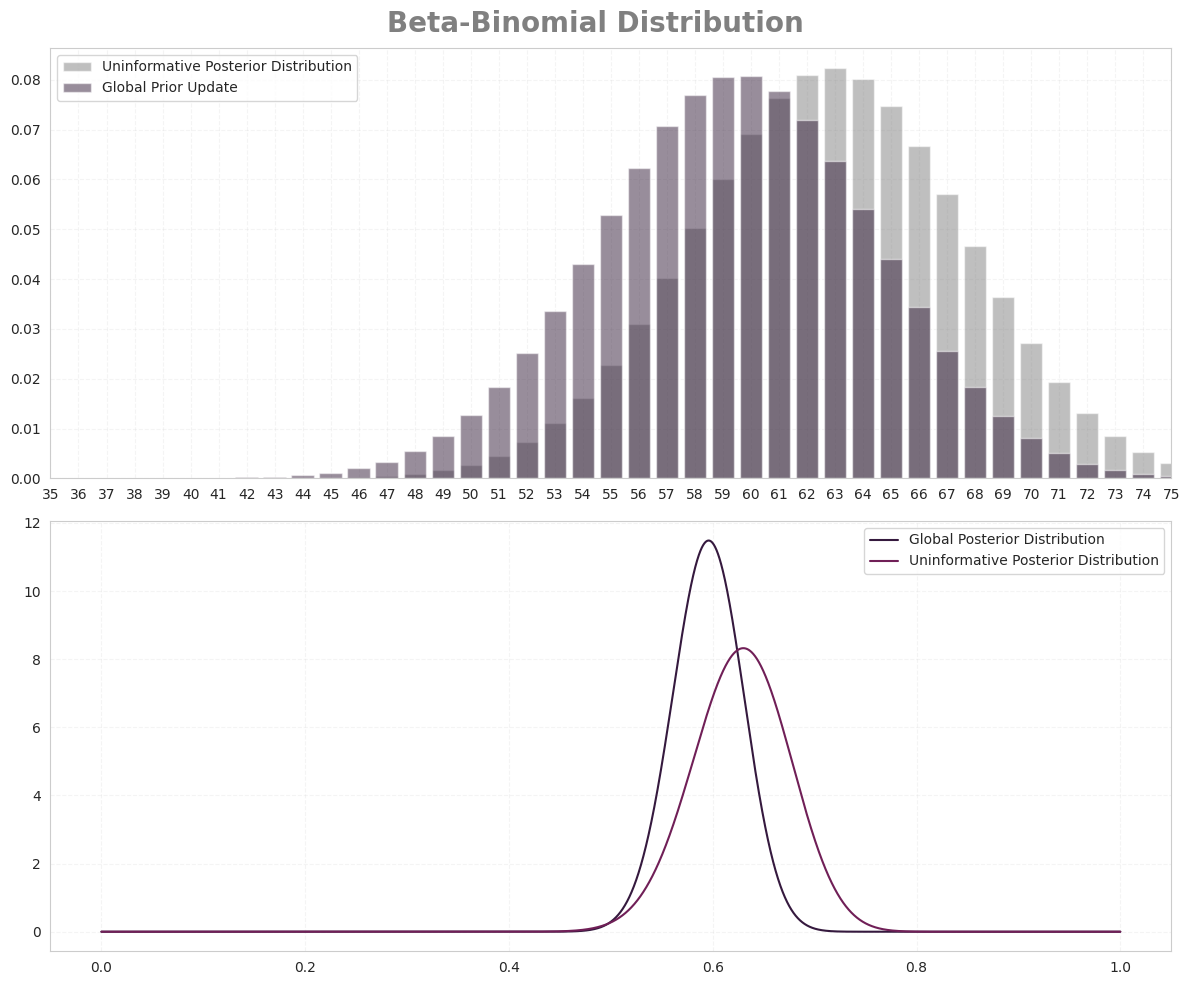

In [42]:
# review 30-59 Minutes group
Baysian_Beta_Binom(prior_sample_size=100,Departure_delay='30-60 Minutes')

--- Posterior Summary: 60-120 Minutes ---
P(unhappy | delay) [Uninformative Prior]: 0.637
P(unhappy | delay) [Global Prior]:        0.600
Credible range [Uninformative]: 0.542 - 0.727
Credible range [Global Prior]:  0.531 - 0.667


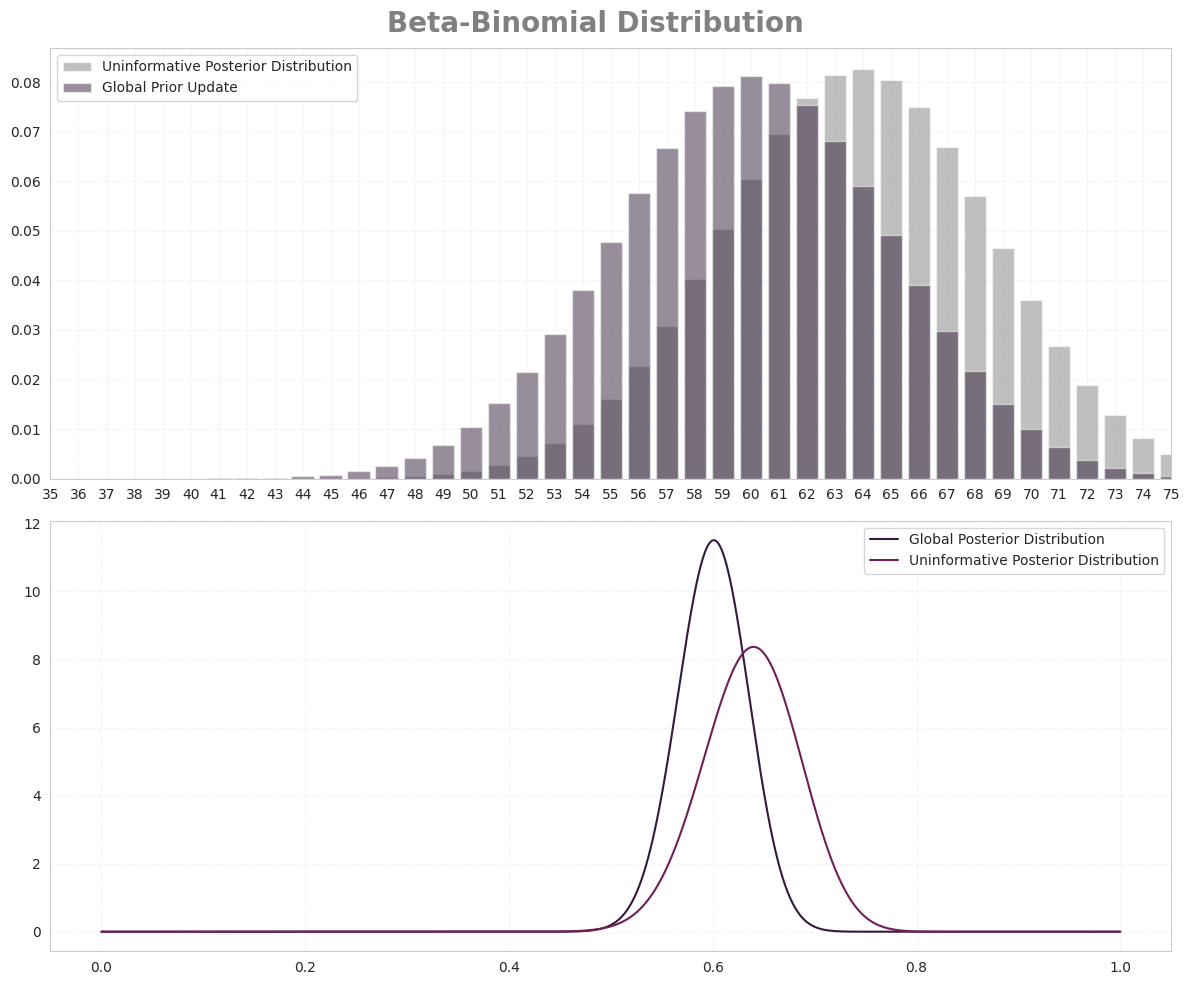

In [43]:
Baysian_Beta_Binom(prior_sample_size=100,Departure_delay='60-120 Minutes')

--- Posterior Summary: 120 Minutes + ---
P(unhappy | delay) [Uninformative Prior]: 0.627
P(unhappy | delay) [Global Prior]:        0.595
Credible range [Uninformative]: 0.532 - 0.718
Credible range [Global Prior]:  0.526 - 0.662


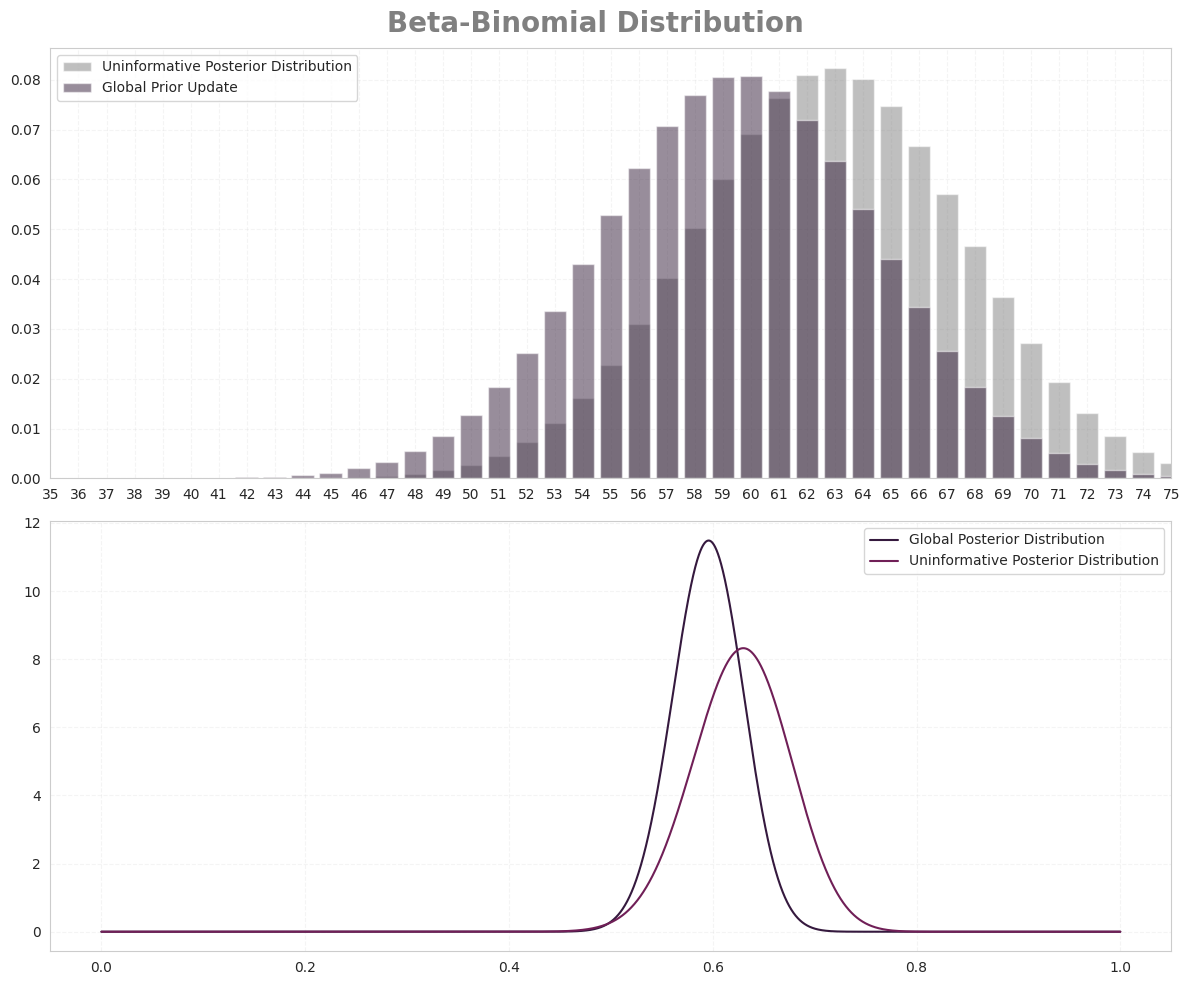

In [44]:
Baysian_Beta_Binom(prior_sample_size=100,Departure_delay='120 Minutes +')

**Notes**

Based on the above results, I have observed the following:

1. All groups except for 1-30 Min Departure Delay group have similar patterns in their Posterior Distributions - The Uninformative Prior differs from the Global Prior. This implies that these groups differ from our overall sample, which suggests that our Global Priors are pulling the Posterior closer to the Global Dissatisfaction rate.
2. All groups have similar Posterior Distribution variances in both Distributions, suggesting that the likelihood is dominant — the data is informative enough that prior choice has little effect on posterior uncertainty.
3. According to our Global Posterior Distributions in all groups, the probability Distribution of P(Unhappy|Given Departure Delay Group) peaks at 60% in group 60-120 Minutes.
4. The Uninformative Posterior Distribution shows a similar pattern but peaks at 64%.
5. The Binomial Distribution then translates this infomration into number of customers expected to be unhappy in 100 trials. For our 60-120minutes group, the Global Posterior Distribution informs the business to expect 60 customers to be unhappy with the Airline and 64 customers in the Uninformative Posterior Distribution.

**Business Application**

Delays are painful and frustrating, but there appears to be little evidence to show that the longer the delay more customers will be unhappy. This doesn't mean customers are happy with delays, however, it simply means that if there is some sort of departure delay the customers will rating the Airline negatively. 

A solution to sweeten the customers would be to offer free food and/or refreshments of some kind while they are waiting to depart, as receiving free food and drink is like saying "there is a delay and we know it is frustrating, here is free food and drink to say we are sorry".

**Machine Learning**

It appears that the length of delay doesn't show much signal and perhaps over-complicates the feature for the end model. I will add a binary feature "Delay" and "No Delay" and compare how each feature does in the modelling phase.

In [45]:
"""
Create a feature that combines arrival and departure delays
"""
def delayFeature(df_in):
    conditions = [
        (df_in['Departure Delay in Minutes'] > 0) & (df_in['Arrival Delay in Minutes'] > 0),
        (df_in['Departure Delay in Minutes'] == 0) & (df_in['Arrival Delay in Minutes'] > 0),
        (df_in['Departure Delay in Minutes'] > 0) & (df_in['Arrival Delay in Minutes'] == 0)
    ]
    
    choices = [
        'Departure and Arrival Delay',
        'Arrival Delay Only',
        'Departure Delay Only'
    ]
    
    df_in['Delay_Type'] = np.select(conditions, choices,default='No Delays')

    df_in.drop(columns=['Departure Delay in Minutes','Arrival Delay in Minutes'], inplace=True)

    return df_in

# drop delay features
train_df5,test_df5 = delayFeature(train_df4),delayFeature(test_df4)

In [46]:
"""
Lets run a quick experiment to see how the data changes when we introduce a new variable - Arrival Delay
"""

def MultiVariate_Bayesian_Analysis(prior_sample_size: int,Departure_delay: str, arrival_and_depart_group: str, data_in):
    binom_dist = stats.binom
    beta_dist = stats.beta
    
    # =================================================================================
    #                             The Prior set up
    # =================================================================================
    # calculate the priors
    uninformative_prior_alpha = 1 # success (dissatisfaction)
    uninformative_prior_beta = 1 # failure (satisfied)
    
    # we are using a small sample size so that we are not using a super strong prior, hence not using the entire sample.
    # if we used the entire sample, we woud have a really strong Prior which makes an overconfident distribution
    
    global_prior = (
        data_in['satisfaction']
        .value_counts(normalize=True)
        .reset_index()
    )
    
    # get alpha and beta
    alpha = global_prior['satisfaction']=='neutral or dissatisfied'
    global_alpha = int(global_prior['proportion'].loc[alpha].iloc[0] * prior_sample_size)
    global_beta = prior_sample_size-global_alpha
    
    # sample the groups
    filter_mask = (data_in['DepartureDelayBuckets']==Departure_delay)&(data_in['Delay_Type']==arrival_and_depart_group)
    first_group = data_in.loc[filter_mask].copy()
    first_group_n = len(first_group)
    
    # calculate the alpha and beta for group. 
    pass_fail = (
        first_group['satisfaction']
        .value_counts(normalize=True)
        .reset_index()
    )
    
    mask = pass_fail['satisfaction']=='neutral or dissatisfied'
    group_alpha = int(pass_fail['proportion'].loc[mask].values[0] * prior_sample_size)
    group_beta = prior_sample_size - group_alpha
    
    # =================================================================================
    #                             The Beta Distribution
    # =================================================================================
    
    
    
    x_vals = np.linspace(0,1,10000)
    beta_dist_res = beta_dist.pdf(
        x=x_vals,
        a=(group_alpha+global_alpha),
        b=(group_beta+global_beta)
    )
    
    uninformative_beta_dist_res = beta_dist.pdf(
        x=x_vals,
        a=(group_alpha+uninformative_prior_alpha),
        b=(group_beta+uninformative_prior_beta)
    )
    
    
    # =================================================================================
    #                             The Binomal Distribution
    # =================================================================================
    
    #extract the posterior distribution mean
    uninformative_mean = beta_dist.mean(
        a=(group_alpha+uninformative_prior_alpha),
        b=(group_beta+uninformative_prior_beta)
    )
    
    global_prior_mean = beta_dist.mean(
        a= (group_alpha+global_alpha),
        b= (group_beta+global_beta)
    )
    
    n_trials = 100
    binom_x = range(0,101,1)
    uninformative_binomial_update = binom_dist.pmf(binom_x,n_trials,uninformative_mean)
    global_prio_binomial_update = binom_dist.pmf(binom_x,n_trials,global_prior_mean)
    # =================================================================================
    #                             Beta Mean Summary
    # =================================================================================
    print(f"--- Posterior Summary: {Departure_delay} ---")
    print(f"P(unhappy | delay) [Uninformative Prior]: {uninformative_mean:.3f}")
    print(f"P(unhappy | delay) [Global Prior]:        {global_prior_mean:.3f}")
    print(f"Credible range [Uninformative]: {beta_dist.ppf(0.025, group_alpha+uninformative_prior_alpha, group_beta+uninformative_prior_beta):.3f} - {beta_dist.ppf(0.975, group_alpha+uninformative_prior_alpha, group_beta+uninformative_prior_beta):.3f}")
    print(f"Credible range [Global Prior]:  {beta_dist.ppf(0.025, group_alpha+global_alpha, group_beta+global_beta):.3f} - {beta_dist.ppf(0.975, group_alpha+global_alpha, group_beta+global_beta):.3f}")
    # =================================================================================
    #                             Show the results
    # =================================================================================
    fig,axes= plt.subplots(
        2,1,figsize=(12,10)
    )
    
    sns.barplot(
        x=binom_x,
        y=uninformative_binomial_update,
        ax=axes[0],
        label='Uninformative Posterior Distribution',
        alpha=0.5,
        color='grey'
    )
    
    sns.barplot(
        x=binom_x,
        y=global_prio_binomial_update,
        ax=axes[0],
        label='Global Prior Update',
        alpha=0.5
    )
    
    axes[0].set_xlim(20,80)
    
    sns.lineplot(
        x=x_vals,
        y=beta_dist_res,
        label='Global Posterior Distribution',
        ax=axes[1]
    )
    sns.lineplot(
        x=x_vals,
        y=uninformative_beta_dist_res,
        label='Uninformative Posterior Distribution',
        ax=axes[1]
    )
    
    for i in range(2):
        axes[i].grid(
            linestyle='--',
            alpha=0.2
        )

    plt.suptitle(
        "Beta-Binomial Distribution",
        fontsize=20,
        fontweight='bold',
        color='grey'
    )
    plt.tight_layout()

--- Posterior Summary: 1-30 Minutes ---
P(unhappy | delay) [Uninformative Prior]: 0.608
P(unhappy | delay) [Global Prior]:        0.585
Credible range [Uninformative]: 0.512 - 0.700
Credible range [Global Prior]:  0.516 - 0.652


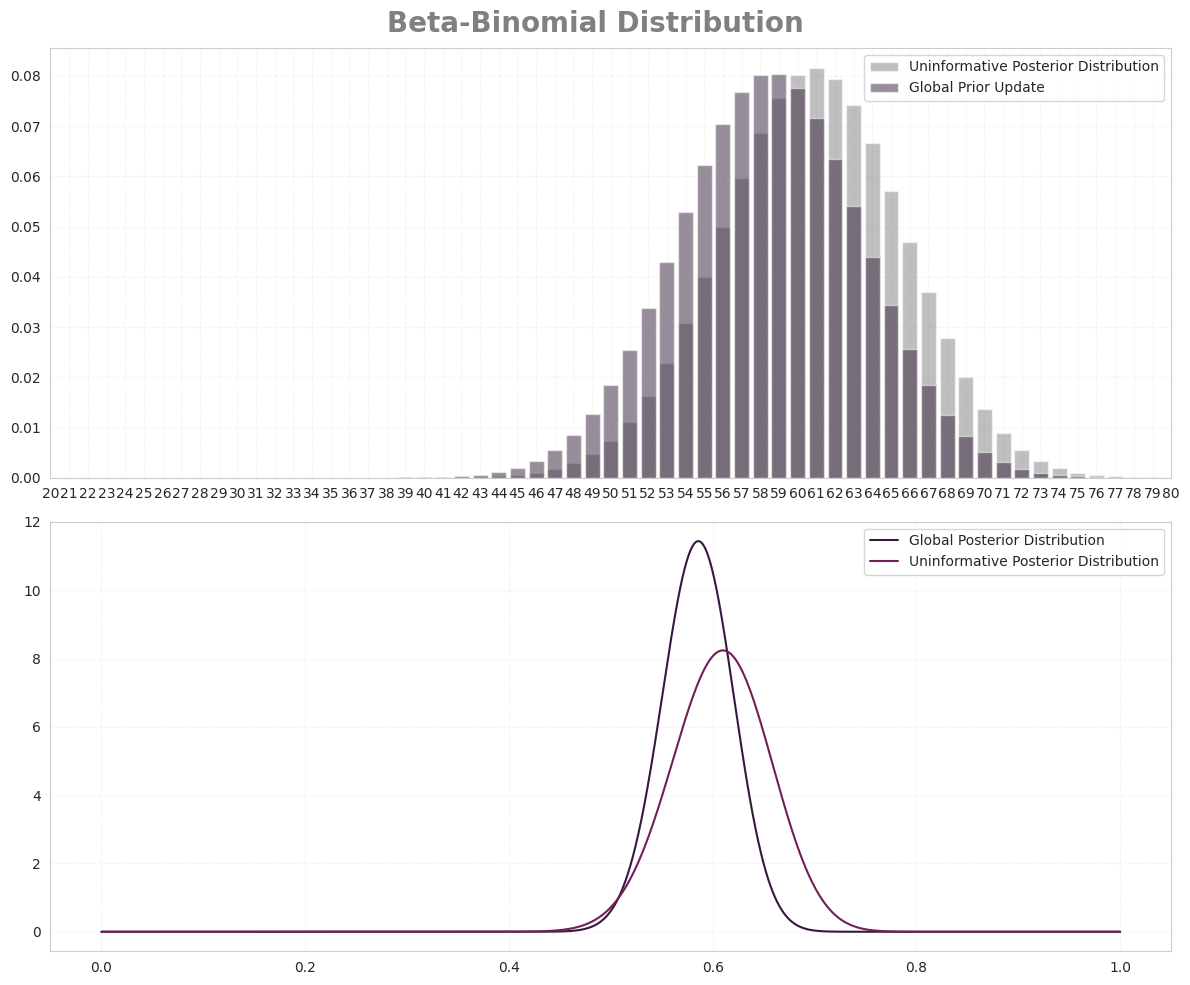

In [47]:
MultiVariate_Bayesian_Analysis(
    prior_sample_size=100,
    Departure_delay='1-30 Minutes', 
    arrival_and_depart_group='Departure and Arrival Delay', 
    data_in=train_df5)

--- Posterior Summary: 1-30 Minutes ---
P(unhappy | delay) [Uninformative Prior]: 0.510
P(unhappy | delay) [Global Prior]:        0.535
Credible range [Uninformative]: 0.413 - 0.606
Credible range [Global Prior]:  0.466 - 0.604


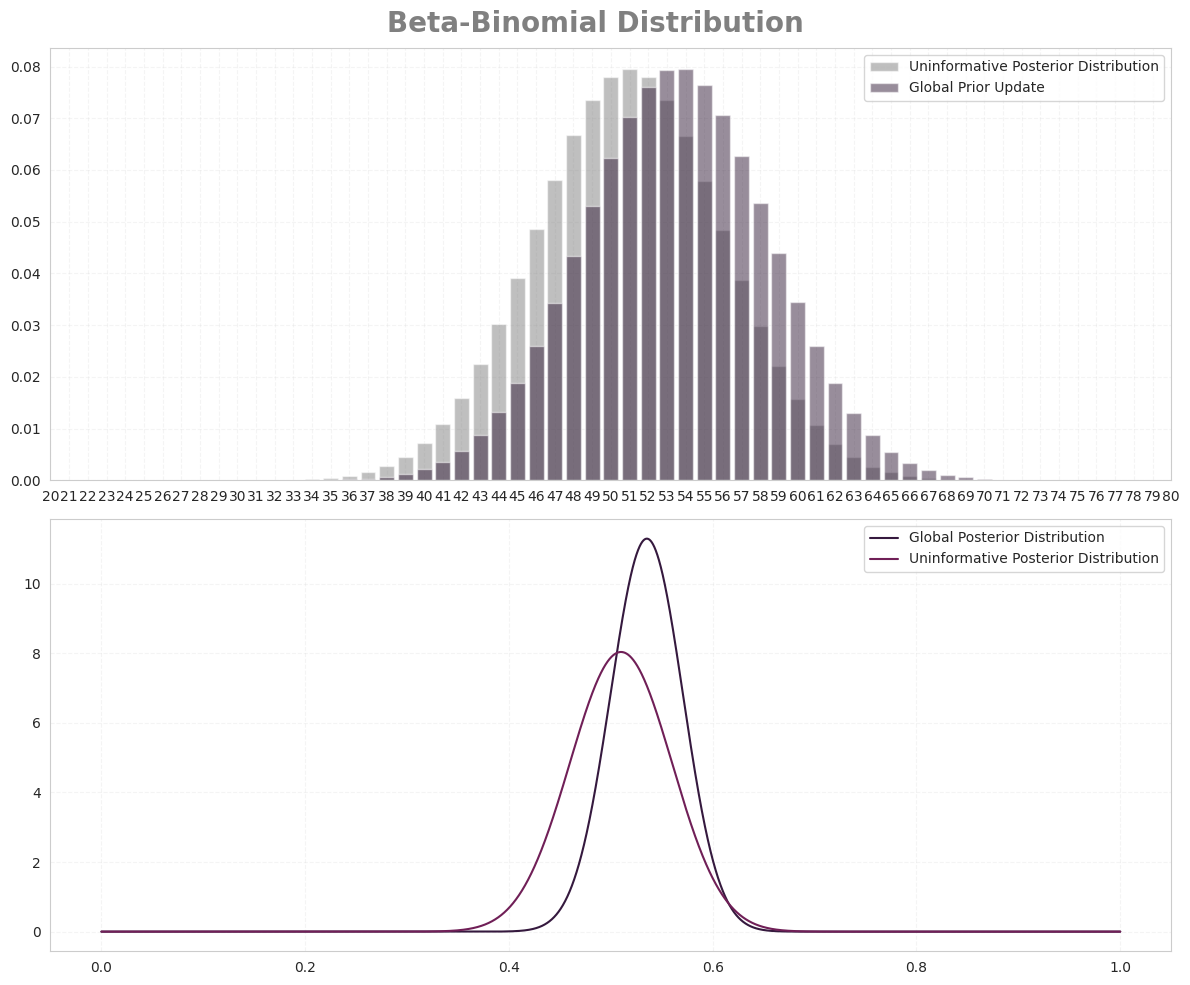

In [48]:
MultiVariate_Bayesian_Analysis(
    prior_sample_size=100,
    Departure_delay='1-30 Minutes', 
    arrival_and_depart_group='Departure Delay Only', 
    data_in=train_df5)

**Notes**

In the first experiment, I analysed Departure delays regardless of whether they arrived on time or not which uncovered some good insights and signals for my model. However, introducing a new variable changes things slightly as it appears that the number of customers, although still quite high, unhappy with the Airline with just a Departure delay decreases while a double delay (Departure and Arrival) increases slightly. This means the Feature Engineering has uncovered a good feature to extract some signal for our prediction.

**Bayesian Perspective**

Compared to our original departure delay groups, both posteriors have shifted slightly to the left on the x-axis, centring around 0.50-0.54 rather than 0.57, suggesting the dissatisfaction rate is lower for departure-only delays than when all delay types are combined.
The variances of our groups are similar to those of previous experiments, where our Global Prior provides a tighter and thinner distribution.
With the new variable introduced, I can have confidence under the Global Prior that P(unhappy|departure and arrival delay) is ~61% and P(unhappy|departure Only) is ~54% which is a 7% difference between the two groups.

**Business Perspective**

The analysis shows signs that a double delay does increase the chance of customers being unhappy relative to just a departure delay. Regardless of this, my previous suggestion of free food and/or drink should still be explored to reduce chances of dissatisfaction. I recommend running experiments to see the impact of this solution to see if it is worth the time and investment.

# Machine Learning

## Data Preparation

In [49]:
# drop unwanted columns
train_df5.drop(columns=['id','Unnamed: 0'],inplace=True)
test_df5.drop(columns=['id','Unnamed: 0'],inplace=True)

# split target and train data
x_train,x_test = train_df5.drop(columns=['satisfaction']).copy(),test_df5.drop(columns=['satisfaction']).copy()
y_train,y_test = train_df5['satisfaction'].copy(),test_df5['satisfaction'].copy()

In [50]:
"""
Build a data transformation pipeline that I can run just by using a function
"""

def data_prep_pipeline(in_df):

    # build pipelines
    num_pipe = Pipeline([
        ('sc',StandardScaler())
    ])
    rating_pipe = Pipeline([
        ('mm', MinMaxScaler())
    ])
    cat_pipe = Pipeline([
        ('ohe',OneHotEncoder())
    ])
    # identify the column types and drop into vars
    # I am going to keep the rating columns as is because 
    # the larger the value (5) the better the customer rated.

    num_column = in_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    num_column_ = [col for col in num_column if col == 'Age']
    rating_column = [col for col in num_column if col != 'Age']
    cat_column = in_df.select_dtypes(exclude=['float64','int64']).columns.to_list()
    
    # join the two pipes together
    preprocessor = ColumnTransformer([
        ('num',num_pipe,num_column_),
        ('cat',cat_pipe,cat_column),
        ('rating',rating_pipe,rating_column)
    ],remainder='passthrough')

    return preprocessor
    
    

In [51]:
train_preprocessor = data_prep_pipeline(x_train)

# transform train and test set
x_train_transformed = train_preprocessor.fit_transform(x_train)
x_test_transformed = train_preprocessor.transform(x_test)


train_preprocessor.get_feature_names_out()

array(['num__Age', 'cat__Gender_Female', 'cat__Gender_Male',
       'cat__Customer Type_Loyal Customer',
       'cat__Customer Type_disloyal Customer',
       'cat__Type of Travel_Business travel',
       'cat__Type of Travel_Personal Travel', 'cat__Class_Business',
       'cat__Class_Eco', 'cat__Class_Eco Plus',
       'cat__DepartureDelayBuckets_0 Mins',
       'cat__DepartureDelayBuckets_1-30 Minutes',
       'cat__DepartureDelayBuckets_120 Minutes +',
       'cat__DepartureDelayBuckets_30-60 Minutes',
       'cat__DepartureDelayBuckets_60-120 Minutes',
       'cat__DistanceType_Long-Haul', 'cat__DistanceType_Medium-Haul',
       'cat__DistanceType_Short-Haul',
       'cat__Delay_Type_Arrival Delay Only',
       'cat__Delay_Type_Departure Delay Only',
       'cat__Delay_Type_Departure and Arrival Delay',
       'cat__Delay_Type_No Delays', 'rating__Flight Distance',
       'rating__Inflight wifi service',
       'rating__Departure/Arrival time convenient',
       'rating__Ease of On

In [52]:

# Just for inspection
col_names = train_preprocessor.get_feature_names_out()
pd.DataFrame(x_train_transformed, columns=col_names).head()

,num__Age,cat__Gender_Female,cat__Gender_Male,cat__Customer Type_Loyal Customer,cat__Customer Type_disloyal Customer,cat__Type of Travel_Business travel,cat__Type of Travel_Personal Travel,cat__Class_Business,cat__Class_Eco,cat__Class_Eco Plus,...,rating__Food and drink,rating__Online boarding,rating__Seat comfort,rating__Inflight entertainment,rating__On-board service,rating__Leg room service,rating__Baggage handling,rating__Checkin service,rating__Inflight service,rating__Cleanliness
0,-1.745279,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.6,1.0,1.0,0.8,0.6,0.75,0.8,1.0,1.0
1,-0.951360,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.2,0.6,0.2,0.2,0.2,1.0,0.50,0.2,0.8,0.2
2,-0.885200,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.8,0.6,0.75,0.8,0.8,1.0
3,-0.951360,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.4,0.4,0.4,0.4,0.4,1.0,0.50,0.2,0.8,0.4
4,1.430397,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.8,1.0,1.0,0.6,0.6,0.8,0.75,0.6,0.6,0.6


In [53]:
satisfaction_map = {'satisfied': 0, 'neutral or dissatisfied': 1}

y_train_transformed = y_train.map(satisfaction_map)
y_test_transformed  = y_test.map(satisfaction_map)

# verify
print(y_train_transformed.value_counts())

satisfaction
1    58879
0    45025
Name: count, dtype: int64


## Base Model

In [54]:
def run_cross_validation(X_train_in, y_train_in, models, cv=5, scoring=None):
    """
    In this function I will be able to analyse model performance over various metrics.
    I have to hold my hands up here in that Claude.ai wrote this, but I made some alterations
    to my liking. That being said, it has taught me new techniques to better analyse model
    performance in experimentations.

    1. always resorts to accuracy if there is no scoring inputted
    2. The standard crossvalidation is applied. We do not have too heavy class imabalance so cross_validate()
       was appropriate and no stratification was selected.
    3. Create a new df that allows for the visualisation of mt results over fold.
    4. Visualise each result over the selected scoring.
    
    """
    if scoring is None:
        scoring = ['accuracy']
    
    results = []
    plot_data = []  # separate list for per-fold plot data

    for name, model in models.items():
        scores = cross_validate(model, X_train_in, y_train_in, cv=cv, scoring=scoring)
        
        # summary row (mean + std per model)
        row = {'model': name}
        for metric in scoring:
            vals = scores[f'test_{metric}']
            row[f'{metric}_mean'] = vals.mean().round(4)
            row[f'{metric}_std']  = vals.std().round(4)
        results.append(row)

        # per-fold rows for plotting
        for fold_idx in range(cv):
            fold_row = {'model': name, 'fold': fold_idx + 1}
            for metric in scoring:
                fold_row[metric] = scores[f'test_{metric}'][fold_idx]
            plot_data.append(fold_row)

    results_df = pd.DataFrame(results).sort_values(f'{metric}_mean', ascending=False)
    plot_df = pd.DataFrame(plot_data)

    # viz
    fig, axes = plt.subplots(
        len(scoring), 1, figsize=(12, 4 * len(scoring))
    )
    if len(scoring) == 1:
        axes = [axes]  # ensure iterable when only 1 metric

    for ax, metric in zip(axes, scoring):
        sns.lineplot(
            data=plot_df,
            x='fold',
            y=metric,
            hue='model',
            marker='o',
            ax=ax
        )
        ax.set_title(
            f'{metric} across folds',
            fontsize=14,
            fontweight='bold',
            color='grey'
        )
        ax.set_xlabel('Fold')
        ax.set_ylabel(metric)
        ax.legend(title='Model')
        ax.grid(
            linestyle='--',
            alpha=0.5
        )

    # add overview title
    plt.suptitle(
        "Cross Validation Results",
            fontsize=20,
            fontweight='bold',
            color='grey',
            x=0.5,
            ha='center',
            y=1.01  # lifts it above the subplots
    )
    plt.tight_layout()
    plt.show()

    return results_df

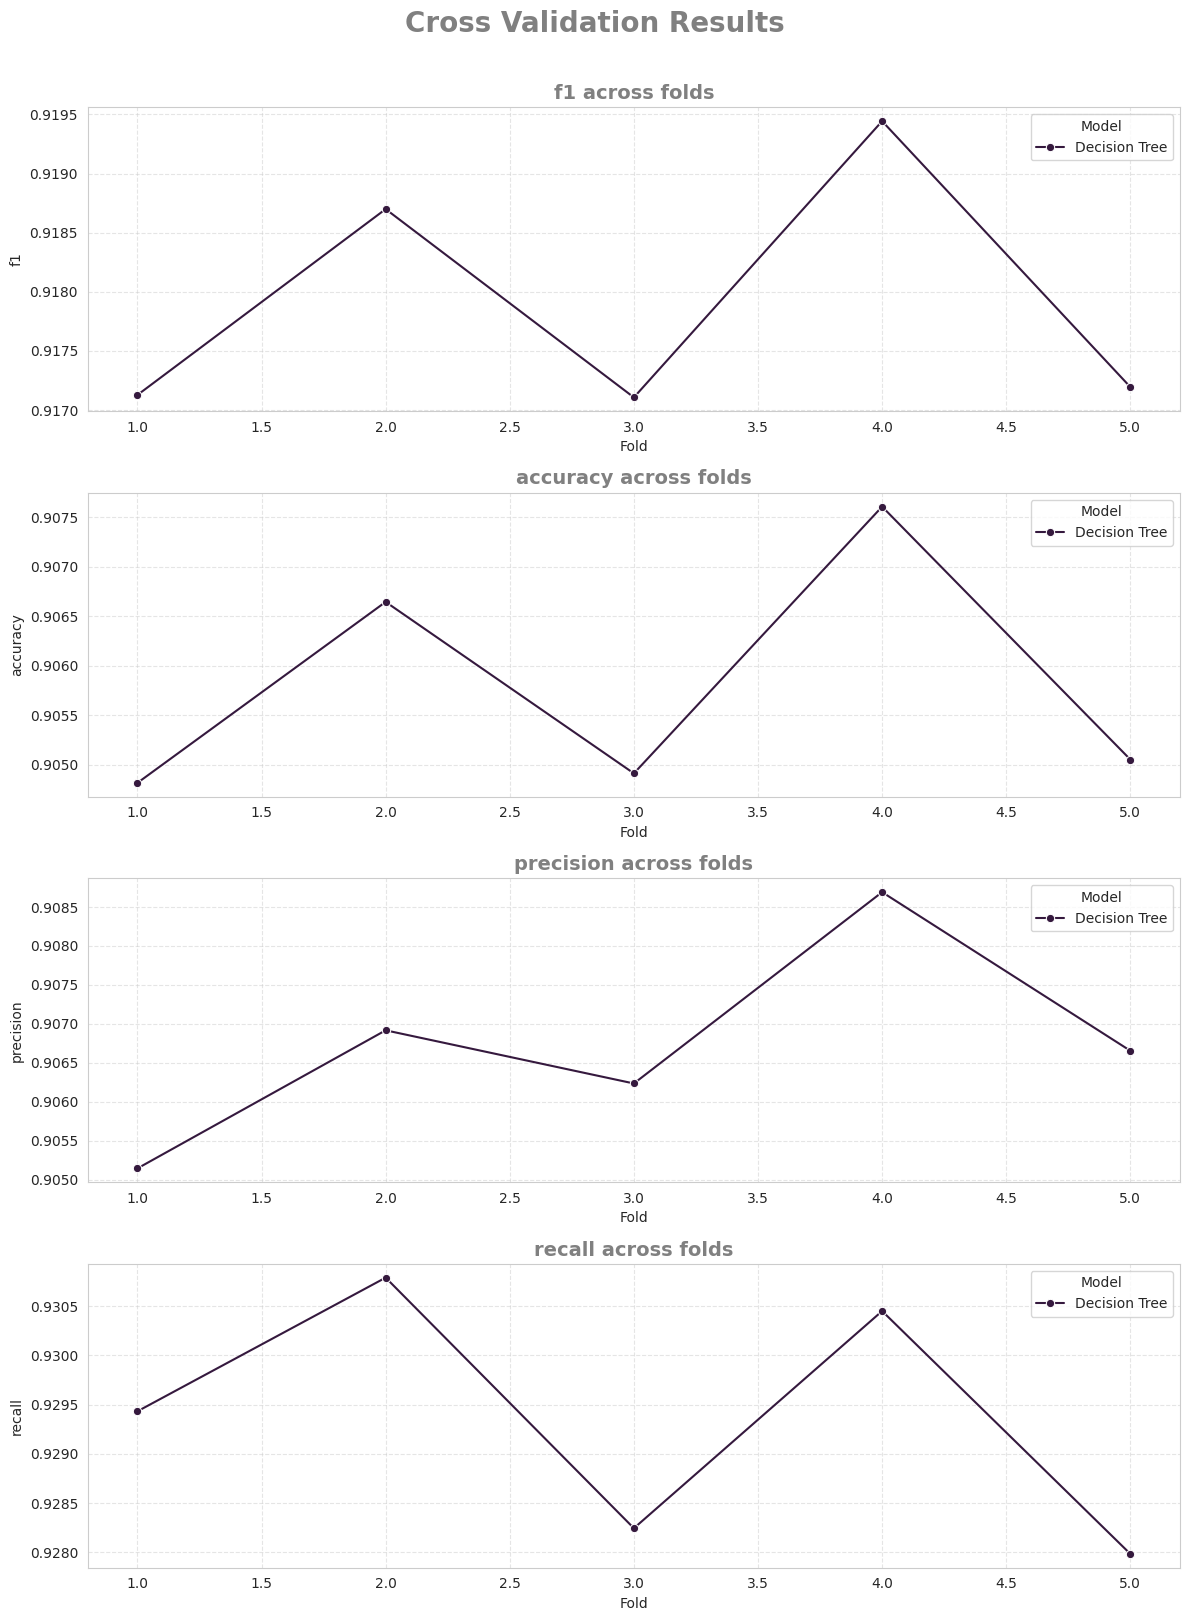

,model,f1_mean,f1_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std
0,Decision Tree,0.9179,0.001,0.9058,0.0011,0.9067,0.0012,0.9294,0.0011


In [55]:

# runn the base model on acc, f1, precision and recall
# The depth is kept small due to the data shape.
# the DT will keep building and building until all features are considered,
# which can take some time to run! Moreover, the large depth of the model means
# that it is likely to overfit the data.
m = {
    'Decision Tree':DecisionTreeClassifier(max_depth=5)
}

# get the results
dt = run_cross_validation(x_train_transformed,y_train_transformed,m,scoring=['f1','accuracy','precision','recall'])

dt

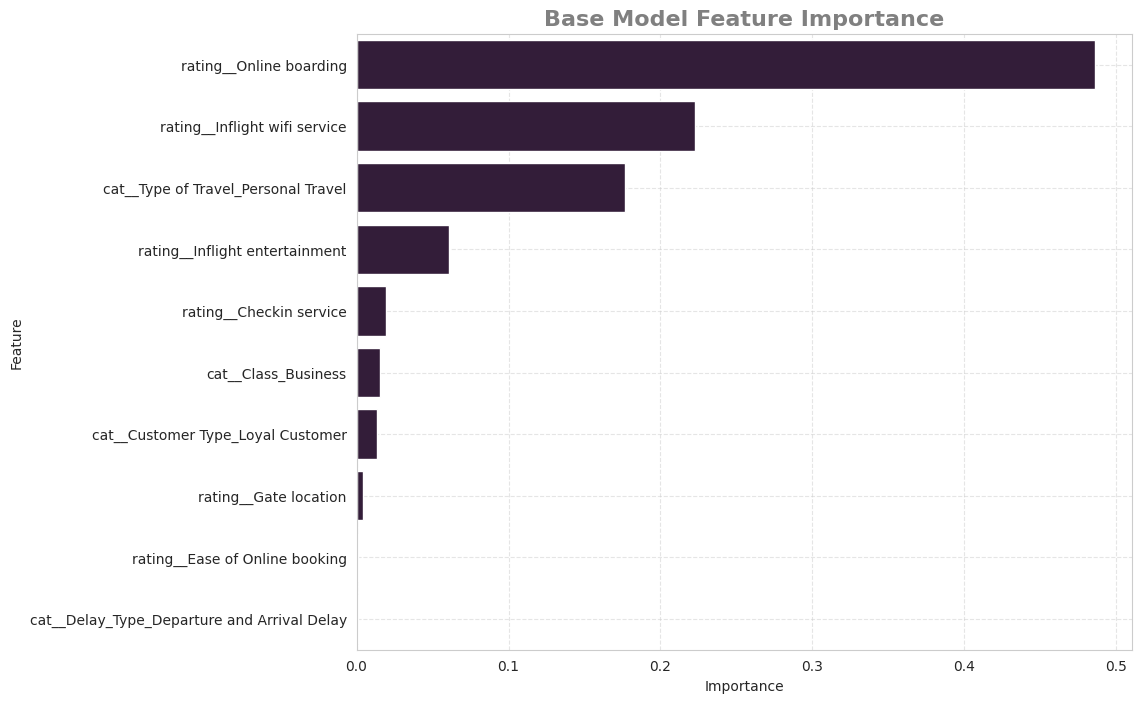

In [56]:
"""
Lets identify the key features used in the base model
"""

dt = DecisionTreeClassifier(max_depth=5)

# fit the training data, but we are not running a test!
# I just want to review those key features

dt.fit(x_train_transformed,y_train_transformed)

# extract features
feature_importance = dt.feature_importances_

#col_names.extend(feature_importanc)
a = list(col_names)

importance_df = (
    pd.DataFrame(
        list(zip(a,feature_importance)),
        columns=['Feature','Importance'])
)

# show the top 10
t10 = importance_df.sort_values(by='Importance',ascending=False).head(10).copy()

plt.figure(
    figsize=(10,8)
)

sns.barplot(
    data=t10,
    x='Importance',
    y='Feature'
);

# add tiitles
plt.title(
    "Base Model Feature Importance",
    fontsize=16,
    fontweight='bold',
    color='grey'
);

plt.grid(
    linestyle='--',
    alpha=0.5
);

# join the features and importance together
#pd.DataFrame([col_names,feature_importance],columns=['Feature','Importance'])

**Notes**

The feature importance has higlighted some interesting insights about the features:

1. Online Boarding appears to be the most important feature in our dataset, suggetsing that their online boarding system is letting the business down. This is interesting because I did not idenntify this feature in the EDA phase even though the avaerage rating were considerably different between the two groups! Human error at its finest!
2. Another interesting point was that Cleanliness was not in the Top 10 mportant features, even though the difference in mean rating was similar to online boarding. The possible reasoning for that is due to its relationship with the other features such as flight distance that diminish its importance.
3. Again, inflight wifi service was not identified in my EDA but the Decision Tree saw it as a key feature. Possible reasons for this would be its relationship with long haul flights, as entertainment on these flights are key for customes to pass the time during the flight.


The next question to pose and answer would be to compare the final models features to the base model and identify what similarities there are.

## Cross Validation

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider

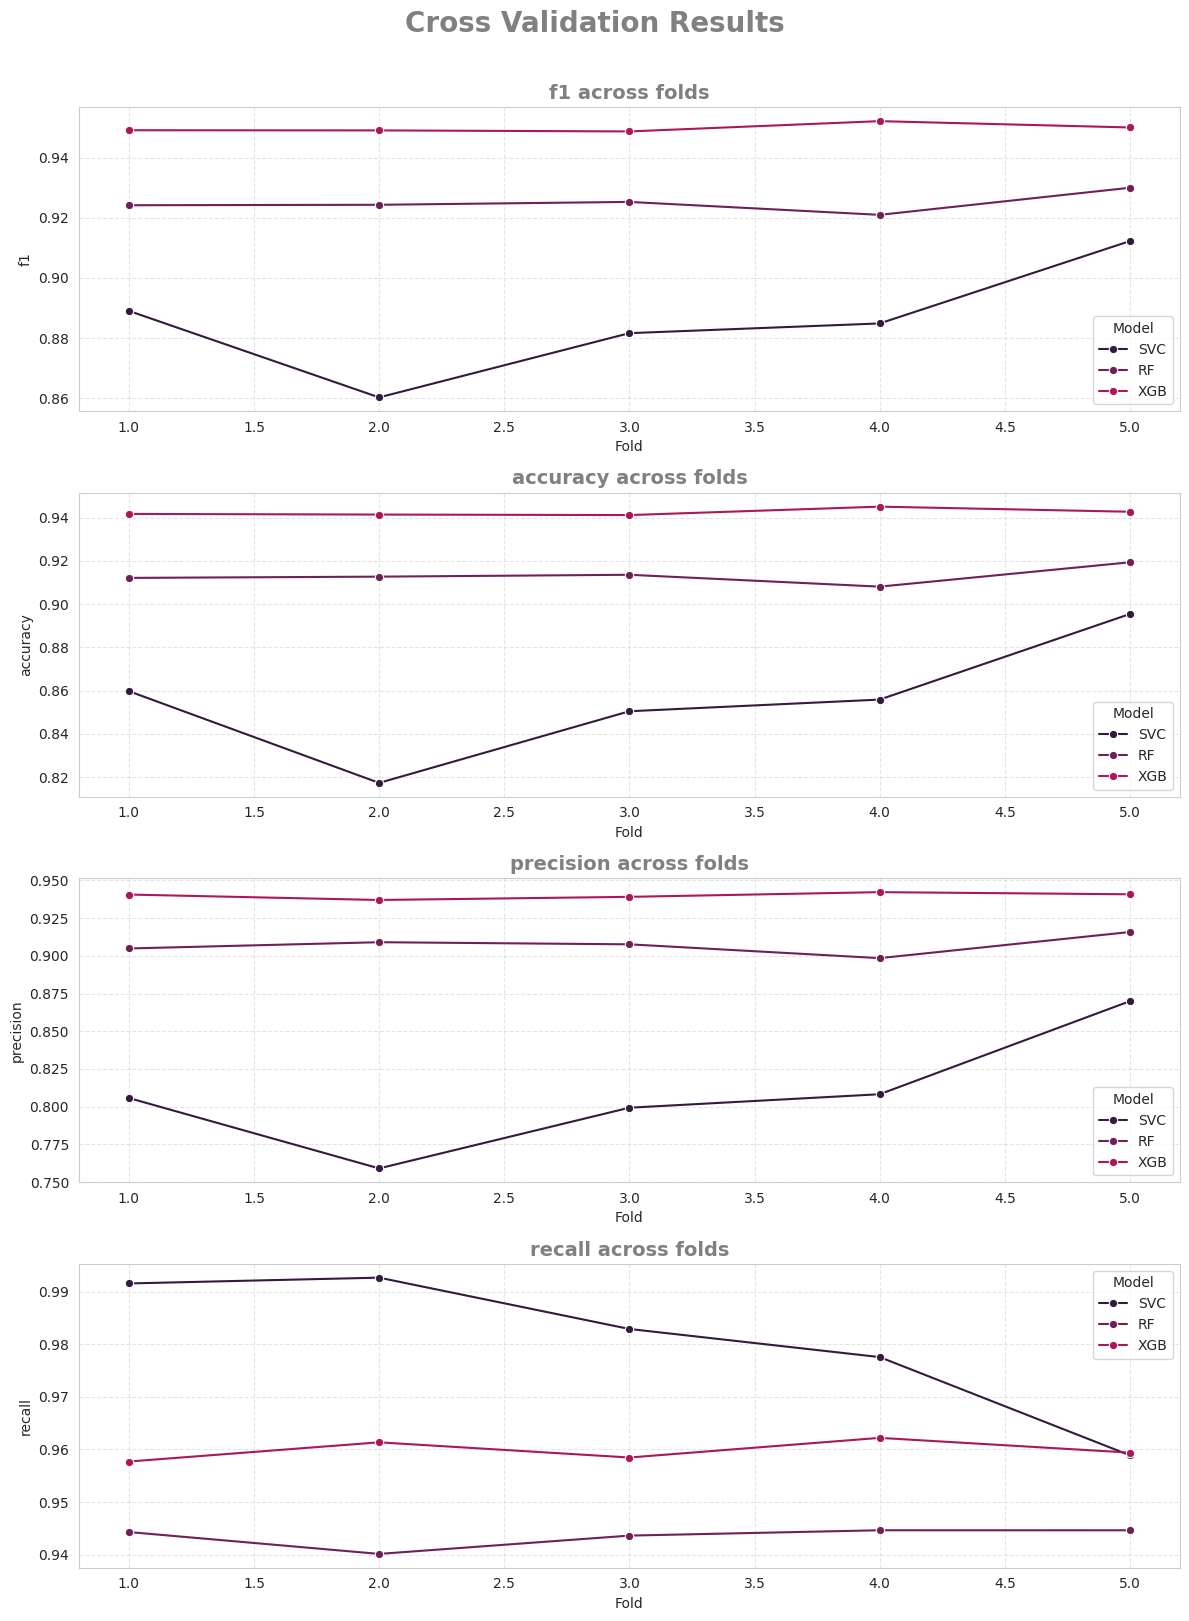

  model  f1_mean  f1_std  accuracy_mean  accuracy_std  precision_mean  \
0   SVC   0.8856  0.0166         0.8558        0.0249          0.8085   
2   XGB   0.9498  0.0012         0.9425        0.0014          0.9399   
1    RF   0.9249  0.0029         0.9132        0.0036          0.9072   

   precision_std  recall_mean  recall_std  
0         0.0355       0.9807      0.0123  
2         0.0018       0.9598      0.0017  
1         0.0056       0.9435      0.0017  


In [57]:
"""
I will follow the same strategy as before where I will restrict the depth of the tree-based models
Given the base model was a single tree with a good prediction accuracy, i am going to
restrict the number of tree to 10.

for SVC model, i will set max_iter to a set value to prevent it from running for a a long time as the
default is unlimited meaning it will keep running until it finds the most optimal solution. Given the amount of features
we have, this could run for a long time!

"""

adv_models = {
    "SVC":SVC(max_iter=4000),
    "RF":RandomForestClassifier(max_depth=5,n_estimators=10, n_jobs=-1),
    "XGB":XGBClassifier(eval_metric='logloss',n_estimators=10,max_depth=5,n_jobs=-1)
}

scoring_in = ['f1','accuracy','precision','recall']

# get the results
MultipleModelsCV = run_cross_validation(x_train_transformed,y_train_transformed,adv_models,scoring=scoring_in)

print(MultipleModelsCV)

**Notes**

A reminder:

Precision -> Of the predicted positive target values, what proportion was accurately predicted?

Recall -> Out of all the positive predictions, how many positive predictions did the model predict correctly?

1. RF is let down by its Recall Score (Mean 94%), which means it had a higher number of False Negatives. This tells me that the RF had are marginally harder time determining unhappy and happy Airline customers.
2. The opposite is true for SVC due to its ~98% Recall, but is let down by its Precision which means it had a high number of False Positives. From a business perspective, this model has a tendancy to predict Unhappy customers when the opposite is true, leading to unwanted actions.
3. XGB has a more blanaced approach to its output due to both Precision and Recall being within the 90%+ brack and sperated by ~2% points, which is evidence by its strong F1 score.


Based on these results, the XGB will be fine tuned and tested on our test dataset!



## Hyperparameter Tuning

OrderedDict({'colsample_bytree': 1.0, 'learning_rate': 0.17720044716834593, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 132, 'subsample': 1.0})
0.9685384073433237


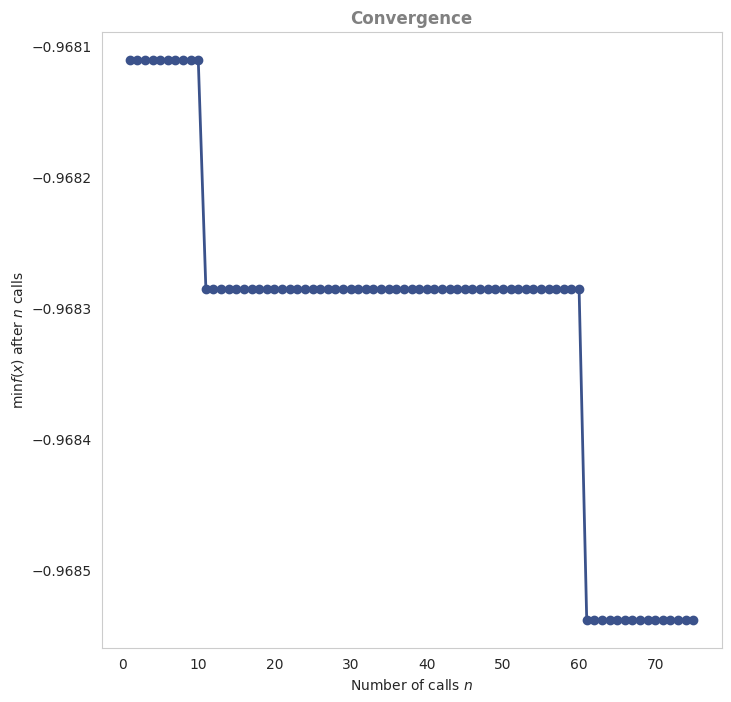

In [58]:
"""
In this section, I am going to use Bayesian Optimisation methods because unlike Random Search, 
it uses each previous step to acquire the best params. In other words, 
it is like mapping out the area of the land based on your previous steps where you 
identify good and bad areas, and use the good areas to determine your next step but 
you do not have the feat of exploring new areas to continue your mapping of the landscape.

"""

xbg_parms = {
    'n_estimators':Integer(10,200),
    'max_depth':Integer(3,8),
    'learning_rate':Real(0.01,0.3, prior='log-uniform'),
    'subsample': Real(0.5, 1.0), #introduces randomness to each tree 
                                #ie if subsamle=0.5, each tree see 50% of the
                                # data, and is randomly sampled
    'colsample_bytree': Real(0.5, 1.0),     # similar to subsample but done by tree, so each tree doesn't
                                            # see a dominant feature.
    'min_child_weight': Integer(1, 10)      # controls how each child leaf is split
}

# I have added subsample because I want to see if randomsampling of data
# upon training increases the models ability to generalise, while only seeing
# a subsample of the data.

# Initiate the Bayesian CV
bayesian_cv = BayesSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    search_spaces=xbg_parms,
    n_iter=75,
    cv=5,         
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

bayesian_cv.fit(x_train_transformed, y_train_transformed)

print(bayesian_cv.best_params_)
print(bayesian_cv.best_score_)

# Access the first (and only) search space result
result = bayesian_cv.optimizer_results_[0]


# show the convergences
# this is simply the visualisation of the minimisation process of the loss function

plt.figure(
    figsize=(8,8)
)
plot_convergence(result)
plt.title("Convergence", fontweight='bold', color='grey')
plt.show()


**Notes**

The maximisation of of our F1 score appears to take small improvements over the total calls, but comparing this to the untuned model you can see a ~2% improvement from the first 10 calls.

The slow appreciation of the objective function suggests that our model has likely started the process with strong parameter selected and built upon them over each call. Therefore, increasing the call greater to what we have now will likely lead to little gain for the cost of resources it will take to run the process.

The three improvement steps shows the Optimiser discovering meaningful parameters spaces but each change plateaus, suggesting the Optimiser is fully exporing/explored the parameter space. This visual evidences the level of superiority it has over other Parameters Search Algorithms due to its ability to purposely find the best parameters that obtain the greatest Objective Finction, rather than randomly searching the parameter spaces then selecting the best options. Moreover, this random searching runs the risk of missing parameter spaces because it has not been explored properly or missed completely.

**The Parameters**

* 'colsample_bytree': 1 -> This means the model builds trees with no random sampling to each tree.
* 'learning_rate': ~0.18 -> A very small learning rate, but makes sense given the depth of the model (depth of 7). However, it also suggests that the model has done well to maximise similarity scores in each tree to maximise the objective function implying that our feature set is fantastic.
* 'max_depth': 7 -> Given what we know about the learning rate, a max depth of 8 tells me that the model required deeper trees to effectively maximise the similarity scores. Shallow trees are insufficient likely due to the models inability to group high similarity residuals in order to maximise the objective function.
* 'min_child_weight': 1 -> This is the default value which means no pruning was necessary, so the splits created were sufficient to result in a strong F1 score.
* 'n_estimators': 132 -> This is also logical given the depth and learning rate as too many deep trees was likely overkill for the task.
* 'subsample': 1.0 -> The default value, which means the model did not improve when randomness was introduced.



<Figure size 1200x1200 with 0 Axes>

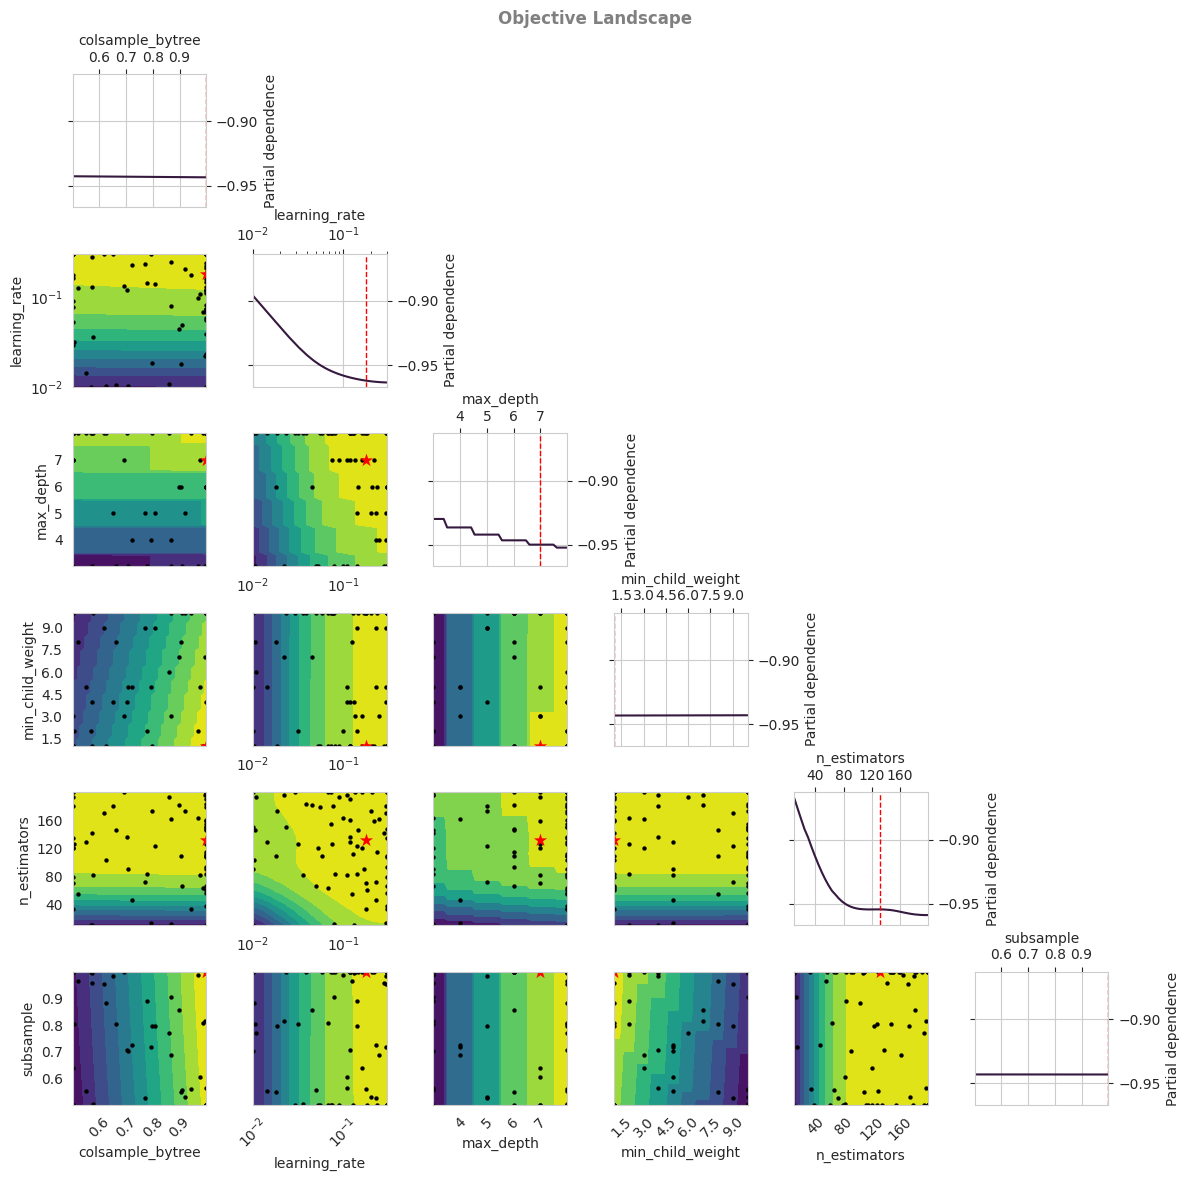

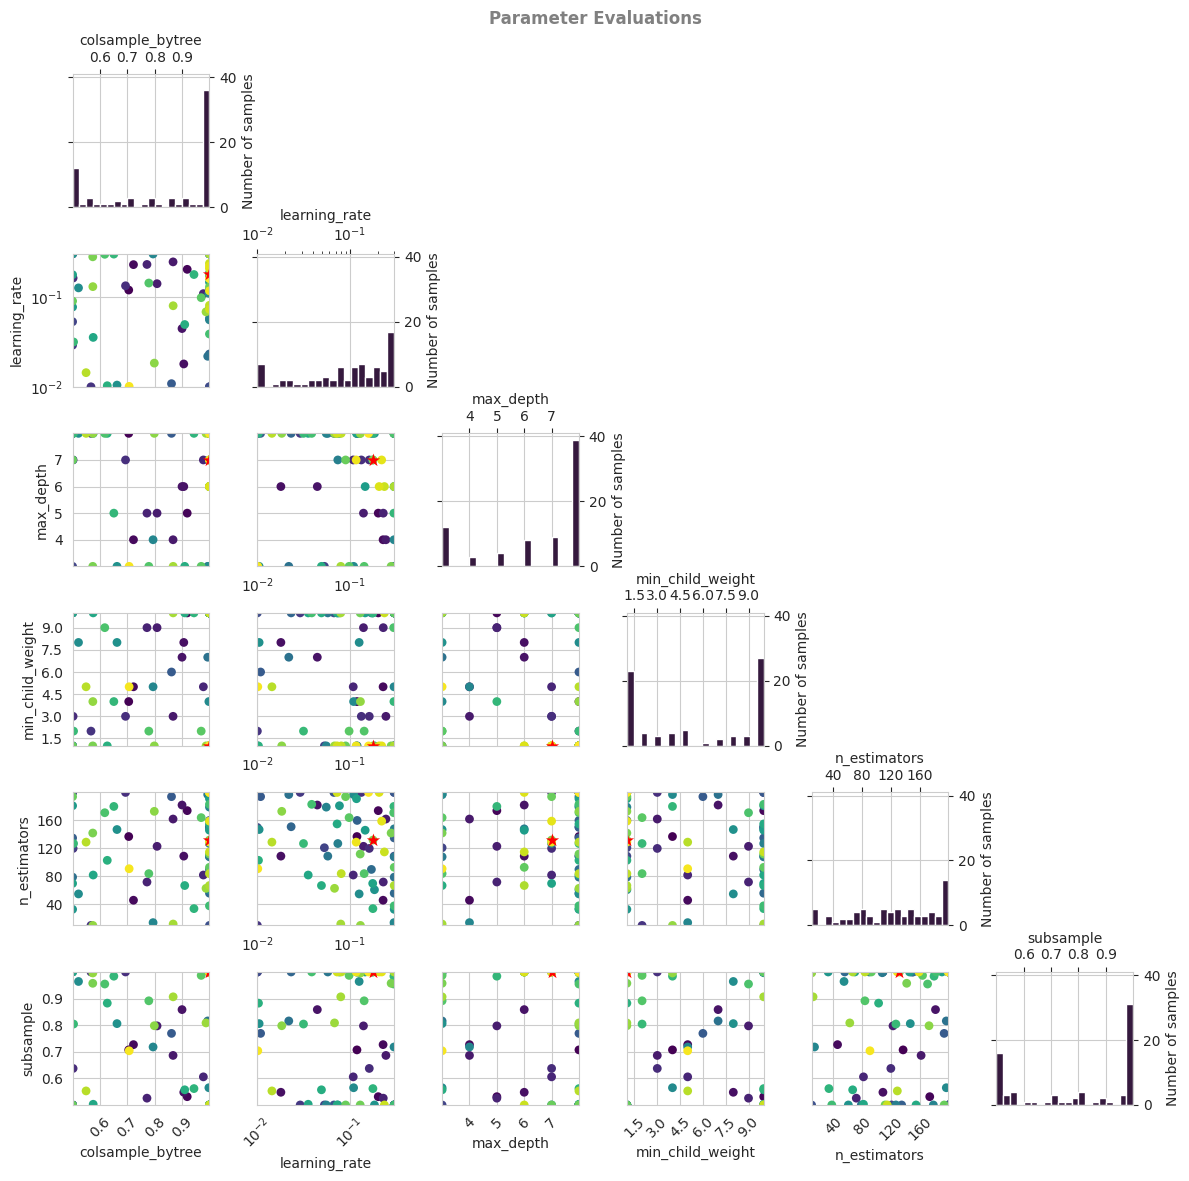

In [59]:
plt.figure(
    figsize=(12,12)
)

plot_objective(result)
plt.suptitle("Objective Landscape", fontweight='bold', color='grey')
plt.tight_layout()
plt.show()

plot_evaluations(result)
plt.suptitle("Parameter Evaluations", fontweight='bold', color='grey')
plt.tight_layout()
plt.show()

**Notes**

1. Even though the min_child_weight was set to 1, you can see the Optimiser testing significantly larger values (up to 9), but the reward that insignificant as the Objective Function did not change after each value. This provides evidence that the XGB classifier did not require any pruning and had sufficient signal from the features to split effectively that maximises similarity scores.
2. n_estimators tells a different story as is shows a steep decline as the Optimiser chose larger values -> the slope dramatically declines as it approaches 80 then plateaus after that point. This tells me that increasing the Parameter space past 200 is likely to provide minimal return due to the small decline after 80.
3. Max Depth smlowly declines as the depth increases but it is a lot more steadier relative to n_estimators. This tells me two things
   1. Increasing the search space will likely provide little improvement.
   2. n_estimators appears to have a greater impact on the model performance, suggesting that ensemble depth — the number of trees — contributes more to model performance than individual tree depth in this context.
4. Learning rate follows a similar story to n_estimators in terms of its influence on model performance. However, it is interesting that the model tended to use values around ~0.1 due to the collection of data in the Histogram.




The exploration of the Parameter space shows a preference for deep tress but in shorter quantity, likely due to the number of features used. The next step is to refine the model by reducing the number of features while keeping the parameters the same.

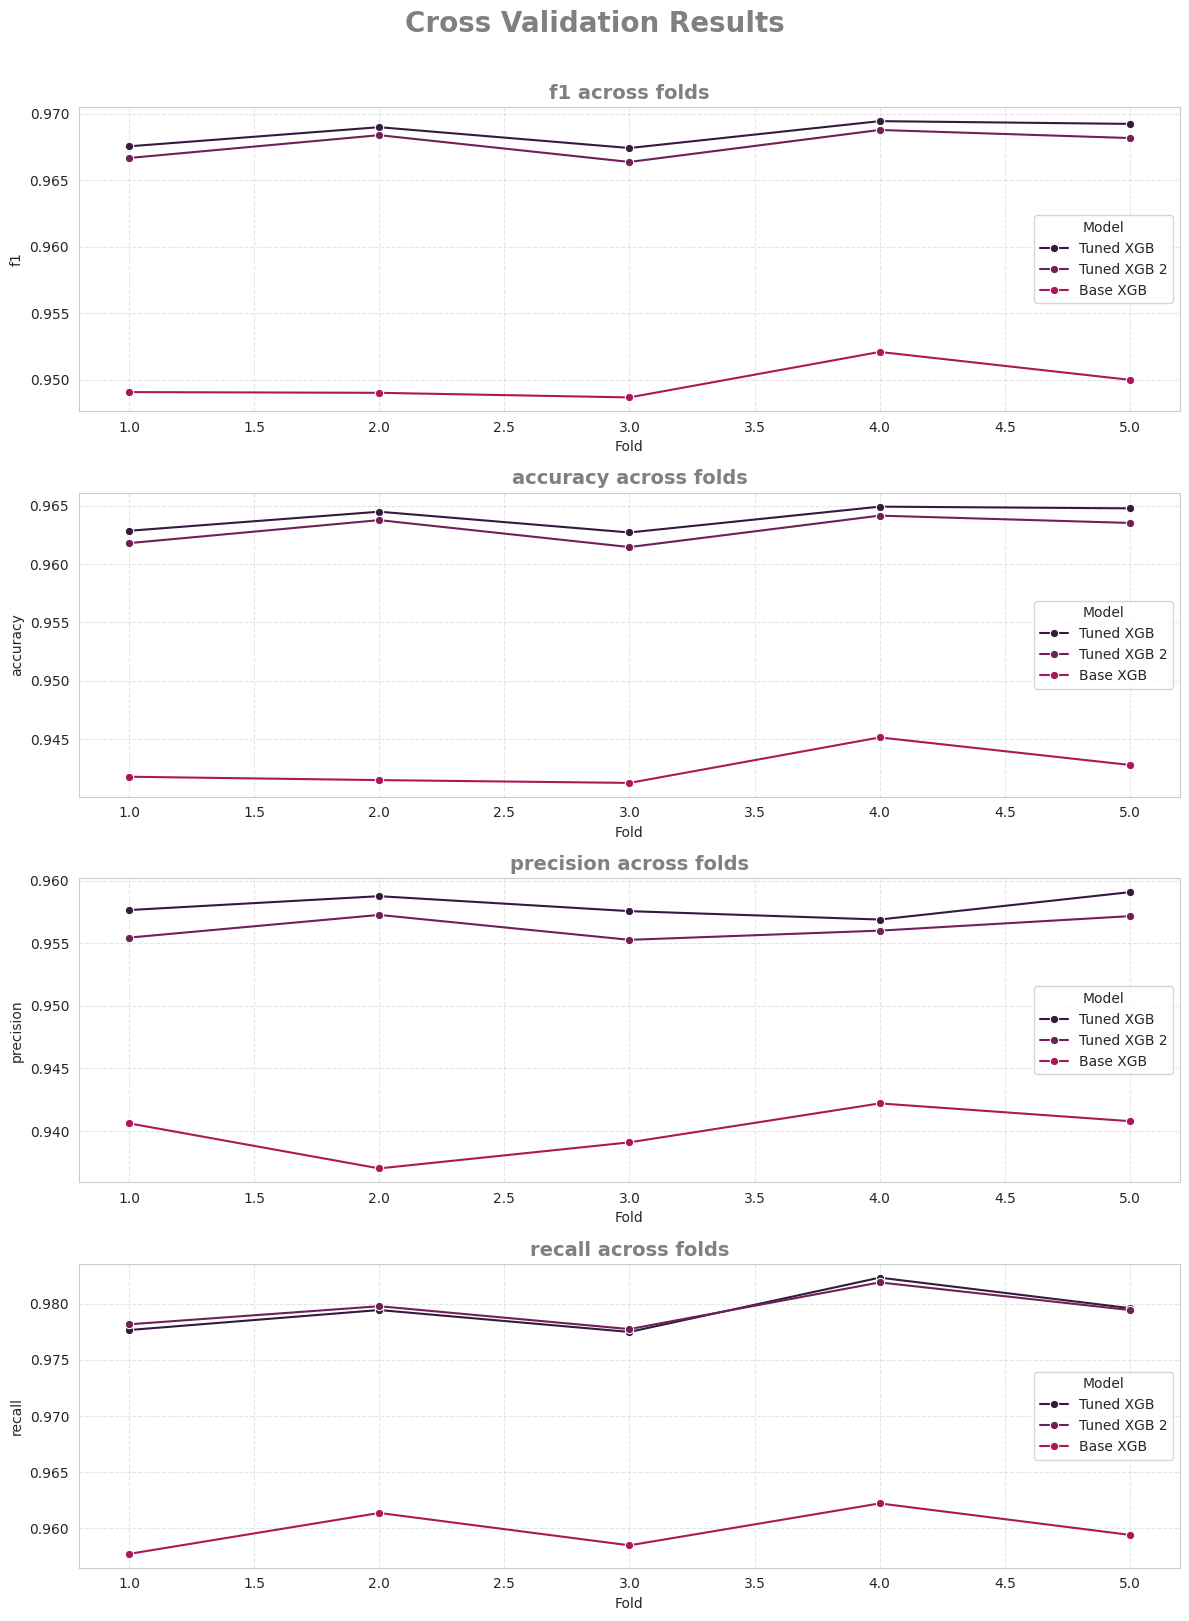

         model  f1_mean  f1_std  accuracy_mean  accuracy_std  precision_mean  \
1  Tuned XGB 2   0.9677  0.0010         0.9629        0.0011          0.9562   
0    Tuned XGB   0.9685  0.0009         0.9639        0.0010          0.9580   
2     Base XGB   0.9498  0.0012         0.9425        0.0014          0.9399   

   precision_std  recall_mean  recall_std  
1         0.0008       0.9794      0.0015  
0         0.0008       0.9793      0.0017  
2         0.0018       0.9598      0.0017  


In [68]:
"""
Lets run the tuned and untuned XGB against  each other in a Cross Validation.

I want to see the influence of colsample_bytree on the model so I will input 3 models

1. Base model
2. Tuned model without colsample_bytree
3. Tuned model with colsample_bytree
"""
tune_results = bayesian_cv.best_params_


tuned_v_untuned = {
    'Tuned XGB':XGBClassifier(
        eval_metric='logloss',
        learning_rate=tune_results['learning_rate'],
        max_depth=tune_results['max_depth'],
        n_estimators=tune_results['n_estimators']
    ),
    'Tuned XGB 2':XGBClassifier(
        eval_metric='logloss',
        learning_rate=tune_results['learning_rate'],
        max_depth=tune_results['max_depth'],
        n_estimators=tune_results['n_estimators'],
        colsample_bytree = 0.5
    ),
    'Base XGB':XGBClassifier(
        eval_metric='logloss',
        n_estimators=10,
        max_depth=5,
        n_jobs=-1
    )
}


# run cv
scoring_in = ['f1','accuracy','precision','recall']

# get the results
TuningEval = run_cross_validation(x_train_transformed,y_train_transformed,tuned_v_untuned,scoring=scoring_in)

print(TuningEval)

**Notes**

The influence of colsample_bytree parameter shows a model that has:

1. Stronger bias as the model appears to be have weaker generalisation ability relative to the other model without this parameter.
2. There is a slight cost in the F1 score by introducing this parameter, but this is marginal.
3. The Precision was weakened suggesting Random sampling by Tree weakens the ability for the model to identify True Positives.


Overall, the model with the colsample_bytree appears to be marginally weaker in comparison to its counterpart, suggesting that random sampling by Tree reduces Variance of the model.

Finally, every model tested showed no sign of overfitting due to small fluctuations in their respective scores over each fold, which suggests an effective balance of Variance and Bias in the models.

## Feature Selection

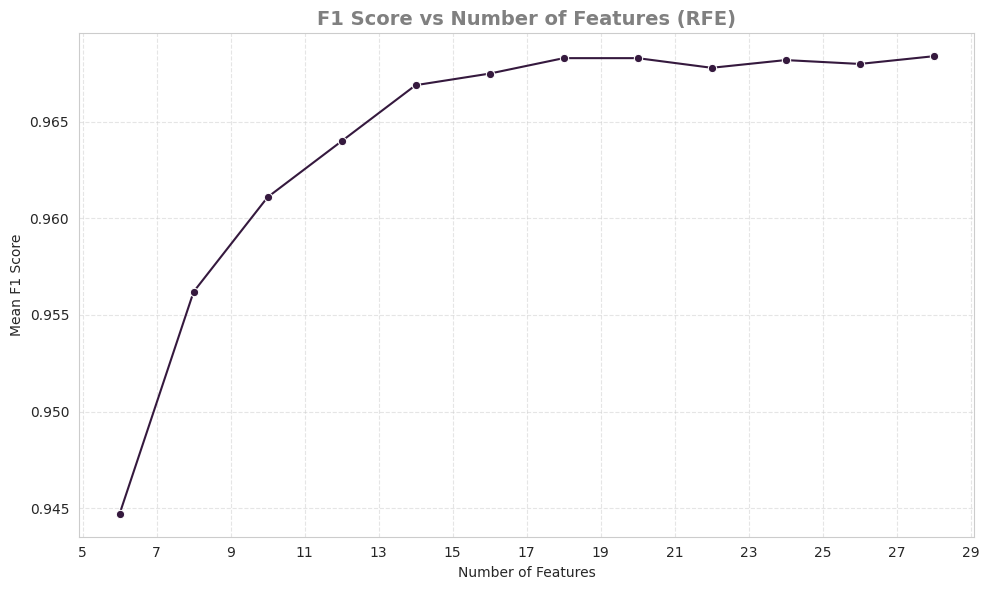

In [63]:
"""

In this section, I am going to experiment with RFE to see which features are the most
appropriate for this model and remove other that add/detract value

we already know that there are 8 potential key featues due to the info gained from out base model.

I will select  up to 0 features and see what happens!

does performance peak at 8 or before? later?

"""
featureCount = range(5, 30, 2)
results = []
feature_combos = []
for i in range(6, 30, 2):
    rfe = RFE(estimator=bayesian_cv.best_estimator_, n_features_to_select=i)
    
    # fit and transform
    rfe.fit(x_train_transformed, y_train_transformed)
    x_train_rfe = rfe.transform(x_train_transformed)

    #get the features
    features_rfe = col_names[rfe.support_]
    
    # get a cv score
    cv = cross_validate(rfe, x_train_transformed, y_train_transformed, cv=5, scoring='f1')
    mean_f1 = cv['test_score'].mean().round(4)
    
    # store results
    feature_combos.append({'n_features': i, 'Features': features_rfe})
    results.append({'n_features': i, 'mean_f1': mean_f1})

# convert to dataframe
results_df = pd.DataFrame(results)

# visualise
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=results_df,
    x='n_features',
    y='mean_f1',
    marker='o'
)
plt.title(
    "F1 Score vs Number of Features (RFE)",
    fontweight='bold',
    color='grey',
    fontsize=14
)
plt.xlabel("Number of Features")
plt.ylabel("Mean F1 Score")
plt.xticks(featureCount)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

**Notes**

We have an opportunity to considerably decrease the Feature Space as the elbow point is situated at 14 features while the max value obtained was sitauted at 18 features. I will select 18 features as I want to maximise the F1 score as much as possible in the final test phase.

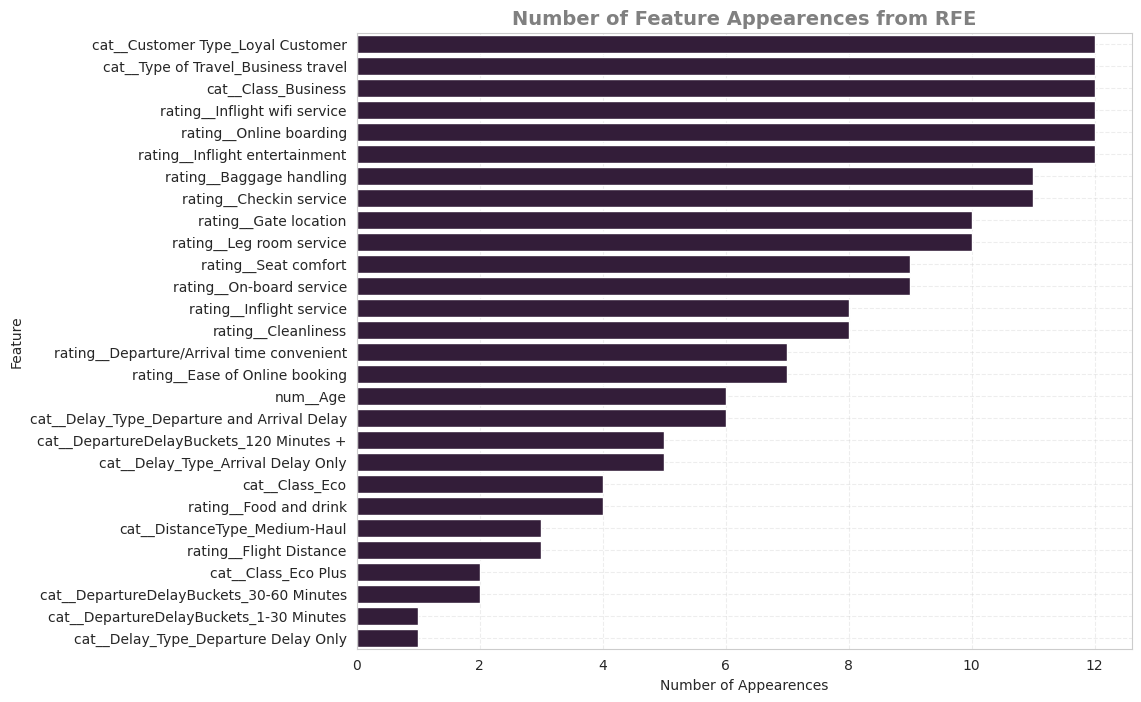

In [72]:
# which features appear consistently?
feature_df_count = pd.DataFrame(feature_combos).explode(column='Features')

count_df = feature_df_count['Features'].value_counts().reset_index()

plt.figure(
    figsize=(10,8)
)
sns.barplot(
    data=count_df,
    x='count',
    y='Features'
)

# adjust viz
plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.title(
    "Number of Feature Appearences from RFE",
    fontweight='bold',
    color='grey',
    fontsize=14
)
plt.xlabel("Number of Appearences")
plt.ylabel("Feature")
plt.grid(linestyle='--', alpha=0.35)

**Notes**

The above chart shows the most frequently used features in the RFE process and shows that Loyal Customer, Business Travel, Class Business Inflight Wifi Service and inflight entertainment were the most frequently used features. This doesn't at all suggest that they are the most powerful in each model, but provides insight into how which feature is likely to appear in the final model.

On the other hand, it does beg the question as to why these features were the commonly employed features for each iteration? Even though they may not be the most significant feature in the model, perhaps the next phase for this project, or other people's work for that matter, would be to explore why these features were employed so often. For example, were loyal customers less likely to be dissatisfied with the Airline because of their loyalty?


In [69]:
# filter data to rfe
rfe = RFE(estimator=bayesian_cv.best_estimator_, n_features_to_select=18)
rfe.fit(x_train_transformed, y_train_transformed)
x_train_rfe, x_test_rfe = rfe.transform(x_train_transformed), rfe.transform(x_test_transformed)


## Final Test

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     11403
           1       0.96      0.98      0.97     14573

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



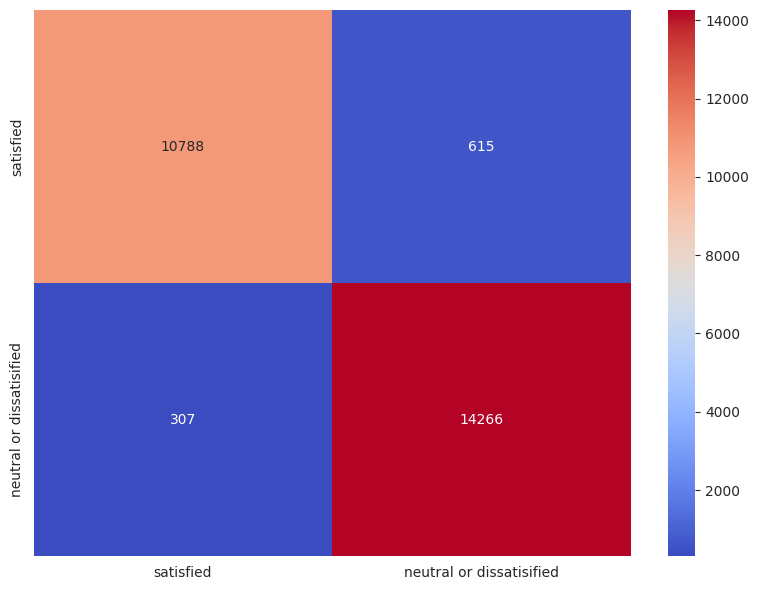

In [70]:
"""
Lets fit the final model and run the predictions
"""
# because we have reduced our feature space, i will retrain the model
final_model = bayesian_cv.best_estimator_
final_model.fit(x_train_rfe, y_train_transformed)


# run the predictions
final_model_preds = final_model.predict(x_test_rfe)

#show results
mtx = confusion_matrix(y_test_transformed,final_model_preds)
report = classification_report(y_test_transformed, final_model_preds)
print(report)

target_labels = ['satisfied','neutral or dissatisified']

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    mtx,
    annot=True,
    cmap='coolwarm',
    fmt='d',
    xticklabels=target_labels,
    yticklabels=target_labels
)

plt.tight_layout()

**Notes**

Precision -> A Precision score of 96% for the Positive Class (Dissatisfied Customers) is excellent as the model is correctly identifying 96/100 dissatisfied customers and falsely predicting 4 customers to be dissatisfied. For the Airline, this means that they be confident in the model's prediction in a production environment but I need to establish the key features which will then provide insight into where they should concentrate their Continuous Improvement efforts.

Recall -> A Recall of 98% means that out of 100 customers, the model was able to predict 98 Dissatisfied Customers while 2 customers were falsely predicted as Satisfied. This indicates a very strong predictive model as it shows very little error in wrongfully predicting Dissatisfied Customers for a Satisified one.

F1 -> The overall model performance is exceptional and is production ready. however, these results do not identify the CI opportunities to prevent future Dissatisfied Customers.

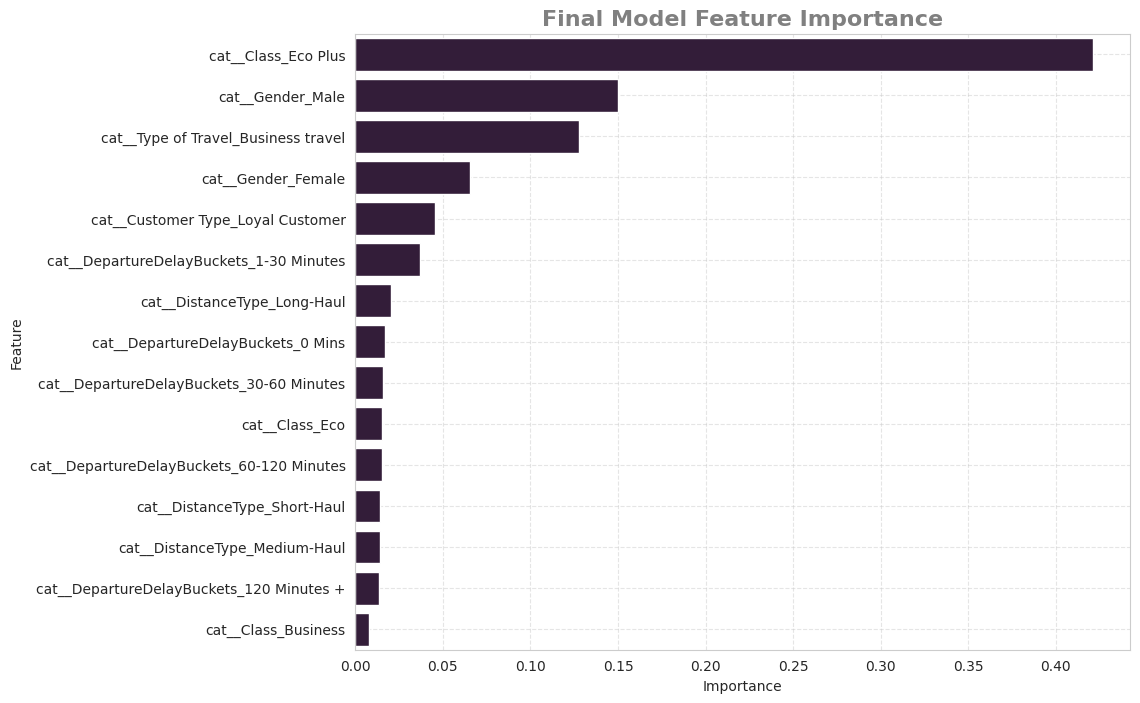

In [71]:
"""
Lets see what the top 10 features are with our model and compare to base model!
"""


# extract features
feature_importance = final_model.feature_importances_

#col_names.extend(feature_importanc)
a = list(col_names)

importance_df = (
    pd.DataFrame(
        list(zip(a,feature_importance)),
        columns=['Feature','Importance'])
)

# show the top 10
t10 = importance_df.sort_values(by='Importance',ascending=False).head(15).copy()

plt.figure(
    figsize=(10,8)
)

sns.barplot(
    data=t10,
    x='Importance',
    y='Feature'
);

# add tiitles
plt.title(
    "Final Model Feature Importance",
    fontsize=16,
    fontweight='bold',
    color='grey'
);

plt.grid(
    linestyle='--',
    alpha=0.5
);

**Notes**

Comparing these features to the RFE, its interesting to see Eco Plus feature as the heavily weighted feature as this was only employed twice in the RFE process. Moreover, it highlights a key gap in my Data Analysis phase as I overlooked these features but provides a valuable lesson -> Start with the least exciting features to understand their relationship with the target variable.

However, the Analysis that I did do along with the related feature engineering provided the model with valuable features to extract signal (such as Departure Delay bucket features). For the Airline, my suggestions still stand and the above provides evidence that mitigation strategies should be employed to ensure customers walk off the plane satisified.

Both gender features may be ethically challenging as it appears men are weighted higher than women in the model. Is this because of the customer demographic or because men are the more dissatisfied with the Airline? Further analysis is required to answer these questions, but it is advised that care and attention is required for these features due to model bias towards men may cause unwanted, unethical business decisions. An example would be Target predicting a female pregnancy before the father even knew about it. 

Link is here -> https://www.forbes.com/sites/kashmirhill/2012/02/16/how-target-figured-out-a-teen-girl-was-pregnant-before-her-father-did/

The next steps for the business should be to investigate how the satisfaction proportions vary over flight class due to their perceived importance in the XGB. Moreover, I would advise the business to explore why these customers in their respective flight class are dissatisfied. Was it because of delays? The services they provide? The plane itself? This information may provide them CI projects to drastically improve their operations, while reducing the number of Dissatisfied Customers.

This project set out to understand what drives airline passenger dissatisfaction. The statistical analysis identified delay type as a meaningful signal — with combined departure and arrival delays increasing dissatisfaction probability by 7% over departure delays alone. The feature engineering captured this signal explicitly through the Delay_Type and DepartureDelayBuckets features — both of which appeared in the final model's feature set, validating the Bayesian analysis findings. The airline's greatest improvement opportunity lies not in operational punctuality, but in the quality of the experience it delivers in their Flight Classes regardless of schedule.
   